# EpiCite · Stage 1 (Weighted Retraining) + Stage 2 (Late-Fusion Transformer)
**Group 12 — AIT NLP** · Biraj Koirala · Longfei Shi

---

## What this notebook does

This is a **self-contained, two-part notebook** that fixes Stage 1's class-imbalance
problem and then builds a stronger Stage 2 citation scorer using a Late-Fusion
Transformer architecture.

### Part A — Stage 1 Retraining with Class Weights
The original Stage 1 DistilBERT was trained with equal loss weight across all
four classes. With 13,225 Claims and only 204 Evidence samples, the model
effectively never learned what Evidence looks like. This part retrains with
**inverse-frequency class weights** so every class contributes fairly to the
loss, regardless of how many samples it has.

### Part B — Stage 2 Late-Fusion Citation Scorer
Instead of feeding only the 18-dim summary vector into XGBoost, we attach a
3-layer MLP directly to the DistilBERT `[CLS]` token. The `[CLS]` embedding
(768-dim) carries the full semantic context of the sentence. We concatenate it
with the 18-dim engineered feature vector and train the MLP head to predict
citation need. This is the **Late-Fusion** architecture: two separate information
streams (semantic + engineered) fused at the final decision layer.

### Training Strategy — Gradual Unfreezing
The MLP head starts from random weights. If we immediately train all 66M
DistilBERT parameters alongside it, the random head produces large gradients
that corrupt the transformer before it can be useful. We prevent this with a
**3-phase gradual unfreezing** schedule:

| Phase | What trains | Why |
|---|---|---|
| 1 — Head only (2 epochs) | MLP only | Stabilise head before touching DistilBERT |
| 2 — Top layers (3 epochs) | MLP + last 2 transformer layers | Let CLS adapt to citation task gently |
| 3 — Full model (2 epochs) | Everything | Conservative global fine-tuning |

### SHAP Explainability — Two-Track Approach
- **Track 1 · KernelExplainer** on the 18 engineered features → bar chart of
  feature importance (answers RQ2 directly)
- **Track 2 · Integrated Gradients** via `captum` on selected sentences →
  token-level attribution heatmaps (qualitative analysis for the report)

---

## File dependencies

| File | Source | Role |
|---|---|---|
| `output/stage1_combined.csv` | Notebook 01 | Stage 1 training corpus |
| `output/stage1_features.csv` | Notebook 02 | Cached spaCy features |
| `output/epicite_stage1_best.pt` | Notebook 02 | Starting checkpoint for retraining |

## Outputs produced

| File | Contents |
|---|---|
| `output/stage1v2_weighted_best.pt` | Stage 1 retrained checkpoint (class-weighted) |
| `output/stage2v2_best_phase1.pt` | Late-Fusion Phase 1 checkpoint |
| `output/stage2v2_best_phase2.pt` | Late-Fusion Phase 2 checkpoint |
| `output/stage2v2_best_final.pt` | Late-Fusion final best checkpoint |
| `output/stage2v2_wiki_features.csv` | Cached WikiSQE spaCy features |
| `output/stage2v2_wiki_epiprobs.csv` | Cached WikiSQE epistemic probabilities |
| `output/stage2v2_shap_bar.png` | Track 1 SHAP feature importance |
| `output/stage2v2_ig_heatmap.png` | Track 2 Integrated Gradients heatmap |
| `output/stage2v2_results.json` | All evaluation metrics |


---
## Section 0 · Setup & Global Configuration

Everything that is shared across both Part A and Part B lives here:
imports, label maps, the spaCy feature extractor, and the device check.
Running this section is mandatory before any other section.


In [ ]:
# !pip install -q transformers datasets torch scikit-learn shap spacy tqdm captum
# !python -m spacy download en_core_web_sm -q


In [1]:
import os, re, json, time, warnings, pickle, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm

import spacy
from spacy.matcher import Matcher

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    accuracy_score, confusion_matrix, brier_score_loss,
    average_precision_score,
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from datasets import load_dataset
import shap

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ─────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING : No GPU detected. Training will be slow.")

# ── Label maps (4-class, shared across all parts) ─────────────────────────────
LABEL2ID   = {"Claim": 0, "Evidence": 1, "Opinion": 2, "Background": 3}
ID2LABEL   = {v: k for k, v in LABEL2ID.items()}
CLASSES    = list(LABEL2ID.keys())
NUM_CLASSES = len(CLASSES)
CLASS_COLORS = {
    "Claim": "#4C72B0", "Evidence": "#55A868",
    "Opinion": "#DD8452", "Background": "#C44E52",
}

# ── Shared paths ────────────────────────────────────────────────────────────────
MODEL_NAME  = "distilbert-base-uncased"
MAX_LEN     = 128
os.makedirs("output", exist_ok=True)

print(f"\nClasses : {CLASSES}")
print(f"Max seq length : {MAX_LEN}")
print("Setup complete.")


Device  : cuda
GPU     : NVIDIA GeForce RTX 2080 Ti
VRAM    : 11.5 GB

Classes : ['Claim', 'Evidence', 'Opinion', 'Background']
Max seq length : 128
Setup complete.


### Shared spaCy Feature Extractor

This is the **same 12-feature extractor from Notebook 02**, defined once here
and reused across both Part A (Stage 1 EDA) and Part B (Stage 2 feature matrix).
Defining it once prevents any silent drift between the two parts.


In [2]:
nlp = spacy.load("en_core_web_sm")

HEDGE_VERBS = [
    "seem","seems","seemed","appear","appears","appeared",
    "suggest","suggests","suggested","indicate","indicates","indicated",
    "propose","tend","tends","tended","believe","believes","believed",
    "assume","assumes","assumed","speculate","speculates","speculated",
    "hypothesize","estimate","estimates","estimated","report","reports","reported",
]
HEDGE_AUX = ["may","might","could","would","should","can"]
HEDGE_ADV = [
    "possibly","probably","perhaps","allegedly","reportedly","presumably",
    "arguably","apparently","supposedly","ostensibly","likely","unlikely",
    "generally","typically","usually","often","sometimes","occasionally",
    "roughly","approximately","potentially","conceivably","purportedly",
]
VAGUE_QUANT = [
    "some","many","few","several","various","numerous","certain","multiple",
    "substantial","considerable","significant","little","much",
]
CITATION_RE = re.compile(
    r'\b(according to|cited by|as shown|as reported|as stated|'
    r'studies show|research shows|evidence suggests|data shows|'
    r'\(\d{4}\)|\[\d+\])\b', re.IGNORECASE
)
NOMIN_SUFFIXES = (
    "tion","sion","ment","ness","ity","ance","ence",
    "ism","age","al","ure","ery","ory",
)

matcher = Matcher(nlp.vocab)
for w in HEDGE_VERBS:
    matcher.add(f"HEDGE_V_{w}",   [[{"LOWER": w, "POS": "VERB"}]])
for w in HEDGE_AUX:
    matcher.add(f"HEDGE_AUX_{w}", [[{"LOWER": w, "POS": "AUX"}]])
for w in HEDGE_ADV:
    matcher.add(f"HEDGE_ADV_{w}", [[{"LOWER": w, "POS": {"IN": ["ADV","ADJ"]}}]])
for w in VAGUE_QUANT:
    matcher.add(f"VAGUE_{w}",     [[{"LOWER": w, "POS": {"IN": ["DET","ADJ","PRON"]}}]])

def extract_features(sentence, doc_sentences=None, sent_idx=0, para_len=1):
    text   = str(sentence)
    doc    = nlp(text)
    tokens = [t for t in doc if not t.is_space]
    n      = max(len(tokens), 1)

    matches     = matcher(doc)
    matched_ids = [nlp.vocab.strings[m[0]] for m in matches]
    hedge_count = sum(1 for mid in matched_ids if mid.startswith("HEDGE_"))
    vague_count = sum(1 for mid in matched_ids if mid.startswith("VAGUE_"))
    superlative = sum(1 for t in doc if t.tag_ == "JJS")

    dep_labels = {t.dep_ for t in doc}
    passive    = int(bool(dep_labels & {"nsubjpass","auxpass","nsubj:pass","aux:pass"}))

    nomin = 0
    for t in tokens:
        morph = str(t.morph)
        if "Nmlz" in morph or "Nmz" in morph:
            nomin += 1
        elif t.pos_ == "NOUN" and t.text.lower().endswith(NOMIN_SUFFIXES):
            nomin += 1

    pos_c = {"NOUN":0,"VERB":0,"ADJ":0,"ADV":0}
    for t in tokens:
        if t.pos_ in pos_c:
            pos_c[t.pos_] += 1

    total_s     = len(doc_sentences) if doc_sentences else 1
    sent_pos    = sent_idx / max(total_s - 1, 1)
    window      = doc_sentences[max(0,sent_idx-2):sent_idx+3] if doc_sentences else [text]
    cit_density = len(CITATION_RE.findall(" ".join(window)))
    para_idx    = sent_idx / max(para_len - 1, 1)

    return {
        "hedge_count":         hedge_count,
        "vague_quant_count":   vague_count,
        "superlative_count":   superlative,
        "passive_voice":       passive,
        "nominalization_rate": nomin / n,
        "pos_noun_ratio":      pos_c["NOUN"] / n,
        "pos_verb_ratio":      pos_c["VERB"] / n,
        "pos_adj_ratio":       pos_c["ADJ"]  / n,
        "pos_adv_ratio":       pos_c["ADV"]  / n,
        "sentence_position":   sent_pos,
        "citation_density":    cit_density,
        "para_relative_idx":   para_idx,
    }

FEATURE_COLS = list(extract_features("Test.").keys())
print(f"Feature extractor ready — {len(FEATURE_COLS)} features:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {f}")


Feature extractor ready — 12 features:
   1. hedge_count
   2. vague_quant_count
   3. superlative_count
   4. passive_voice
   5. nominalization_rate
   6. pos_noun_ratio
   7. pos_verb_ratio
   8. pos_adj_ratio
   9. pos_adv_ratio
  10. sentence_position
  11. citation_density
  12. para_relative_idx


---
---
# PART A · Stage 1 Retraining with Class Weights

## Why are we retraining Stage 1?

In Notebook 02, Stage 1 DistilBERT was trained with **equal loss weight** across
all four classes. The problem: the training corpus is severely imbalanced.

| Class | Count | % of corpus | Loss contribution (equal weight) |
|---|---|---|---|
| Claim | 13,225 | 48% | 48% |
| Background | 11,536 | 42% | 42% |
| Opinion | 2,433 | 9% | 9% |
| Evidence | 204 | 0.7% | 0.7% |

With equal weights, 200 Evidence sentences contribute 0.7% of the total loss.
The model can achieve 99.3% accuracy on non-Evidence sentences while completely
ignoring Evidence. It has no incentive to learn what Evidence looks like.

**The fix: inverse-frequency class weights.** Each class gets a weight inversely
proportional to its frequency, so the model is penalised equally for getting any
class wrong, regardless of how rare it is.

```
weight_c = N_total / (4 × N_c)
```

Evidence's weight would be ~33x — which is too extreme and causes loss instability.
We cap it at **10x** and acknowledge in the report that Evidence remains the
hardest class due to data scarcity.


## A1 · Load Stage 1 Corpus & Compute Class Weights

In [3]:
df = pd.read_csv("output/stage1_combined.csv")
df = df.dropna(subset=["sentence","unified_label"])
df["label_id"] = df["unified_label"].map(LABEL2ID)
df = df[df["label_id"].notna()].reset_index(drop=True)
df["label_id"] = df["label_id"].astype(int)

print(f"Loaded {len(df):,} sentences")
print("\nLabel distribution:")
vc = df["unified_label"].value_counts()
for cls in CLASSES:
    cnt = vc.get(cls, 0)
    pct = cnt / len(df) * 100
    print(f"  {cls:<12}: {cnt:>6,}  ({pct:.1f}%)")


Loaded 27,398 sentences

Label distribution:
  Claim       : 13,225  (48.3%)
  Evidence    :    204  (0.7%)
  Opinion     :  2,433  (8.9%)
  Background  : 11,536  (42.1%)


In [4]:
# ── Compute inverse-frequency class weights ───────────────────────────────────
N = len(df)
MAX_WEIGHT = 10.0   # cap to prevent loss explosion on Evidence (204 samples)

raw_weights = {}
capped      = {}
for cls in CLASSES:
    cnt = (df["unified_label"] == cls).sum()
    w   = N / (NUM_CLASSES * cnt)
    raw_weights[cls] = round(w, 3)
    capped[cls]      = min(w, MAX_WEIGHT)

weight_tensor = torch.tensor(
    [capped[cls] for cls in CLASSES], dtype=torch.float
).to(DEVICE)

print("Class weights (inverse-frequency, capped at 10):")
print(f"  {'Class':<12} {'Raw weight':>12} {'Applied weight':>15}")
print(f"  {'-'*42}")
for cls in CLASSES:
    cap_flag = "  ← CAPPED" if raw_weights[cls] > MAX_WEIGHT else ""
    print(f"  {cls:<12} {raw_weights[cls]:>12.3f} {capped[cls]:>15.3f}{cap_flag}")

print(f"\nWeight tensor: {weight_tensor.cpu().numpy()}")
print("\nIntuition: the model is penalised ~{:.0f}x more for misclassifying "
      "Opinion than Claim.".format(capped["Opinion"] / capped["Claim"]))


Class weights (inverse-frequency, capped at 10):
  Class          Raw weight  Applied weight
  ------------------------------------------
  Claim               0.518           0.518
  Evidence           33.576          10.000  ← CAPPED
  Opinion             2.815           2.815
  Background          0.594           0.594

Weight tensor: [ 0.5179206 10.         2.8152487  0.59375  ]

Intuition: the model is penalised ~5x more for misclassifying Opinion than Claim.


## A2 · EDA — Understanding the Imbalance Before Retraining

Before we fix the imbalance, it's worth visualising exactly what the model
was working with. This EDA motivates the class-weight decision for the report.


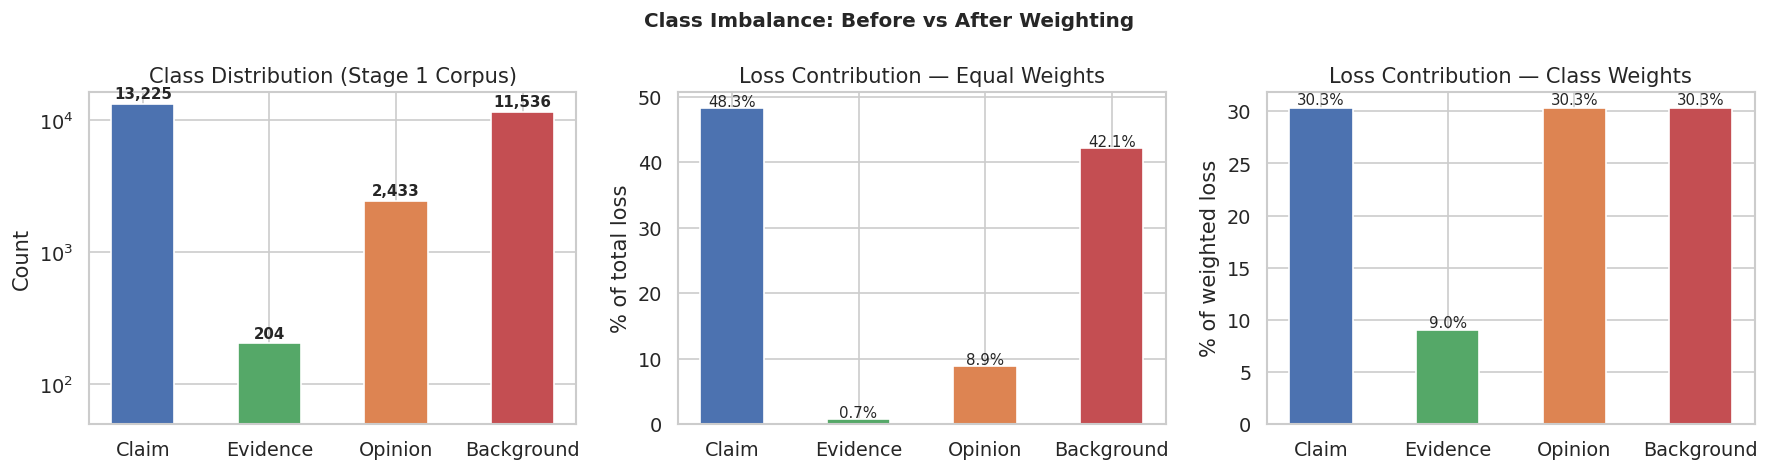

Observation: with equal weights, Evidence contributes <1% of the loss.
With class weights, all classes contribute more evenly.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 1. Class distribution ─────────────────────────────────────────────────────
counts = [vc.get(c, 0) for c in CLASSES]
bars   = axes[0].bar(CLASSES, counts,
                     color=[CLASS_COLORS[c] for c in CLASSES],
                     edgecolor="white", width=0.5)
axes[0].set(title="Class Distribution (Stage 1 Corpus)",
            ylabel="Count")
axes[0].set_yscale("log")   # log scale makes Evidence visible
for b, cnt in zip(bars, counts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()*1.1,
                 f"{cnt:,}", ha="center", fontsize=9, fontweight="bold")
axes[0].set_ylim(bottom=50)

# ── 2. Loss contribution with equal weights ────────────────────────────────────
equal_contrib = [c/N*100 for c in counts]
axes[1].bar(CLASSES, equal_contrib,
            color=[CLASS_COLORS[c] for c in CLASSES],
            edgecolor="white", width=0.5)
axes[1].set(title="Loss Contribution — Equal Weights",
            ylabel="% of total loss")
for i, (cls, pct) in enumerate(zip(CLASSES, equal_contrib)):
    axes[1].text(i, pct+0.3, f"{pct:.1f}%", ha="center", fontsize=9)

# ── 3. Loss contribution with class weights ────────────────────────────────────
weighted_contrib = [capped[cls] * counts[i] for i, cls in enumerate(CLASSES)]
total_w = sum(weighted_contrib)
weighted_pct = [w/total_w*100 for w in weighted_contrib]
axes[2].bar(CLASSES, weighted_pct,
            color=[CLASS_COLORS[c] for c in CLASSES],
            edgecolor="white", width=0.5)
axes[2].set(title="Loss Contribution — Class Weights",
            ylabel="% of weighted loss")
for i, pct in enumerate(weighted_pct):
    axes[2].text(i, pct+0.3, f"{pct:.1f}%", ha="center", fontsize=9)

plt.suptitle("Class Imbalance: Before vs After Weighting", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage1v2_imbalance_eda.png", bbox_inches="tight")
plt.show()

print("Observation: with equal weights, Evidence contributes <1% of the loss.")
print("With class weights, all classes contribute more evenly.")


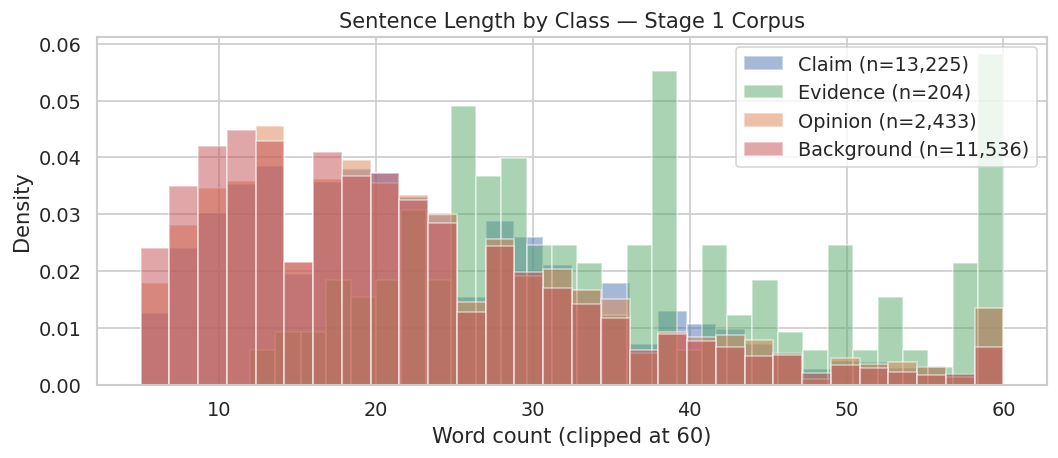

Per-class word count stats:
               mean   std   min    max
unified_label                         
Claim          24.3  13.9   5.0  187.0
Evidence       36.8  15.4  12.0   91.0
Opinion        23.3  14.1   5.0  125.0
Background     21.2  12.3   5.0  108.0


In [6]:
# ── Word length distribution per class ────────────────────────────────────────
# Intuition: do minority classes (Opinion, Evidence) have different length
# profiles? If Evidence sentences are systematically longer or shorter,
# the model might be using length as a proxy — which class weights won't fix.

df["word_count"] = df["sentence"].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 4))
for cls in CLASSES:
    subset = df[df["unified_label"]==cls]["word_count"]
    ax.hist(subset.clip(upper=60), bins=30, alpha=0.5,
            label=f"{cls} (n={len(subset):,})",
            color=CLASS_COLORS[cls], density=True)

ax.set(title="Sentence Length by Class — Stage 1 Corpus",
       xlabel="Word count (clipped at 60)", ylabel="Density")
ax.legend()
plt.tight_layout()
plt.savefig("output/stage1v2_length_eda.png", bbox_inches="tight")
plt.show()

print("Per-class word count stats:")
print(df.groupby("unified_label")["word_count"]
        .describe()[["mean","std","min","max"]]
        .reindex(CLASSES).round(1).to_string())


## A3 · Stratified Train / Val / Test Split

In [7]:
train_df, temp_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_id"]
)

print("Split sizes (stratified — class ratios preserved):")
for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n  {name}: {len(split):,} rows")
    for cls in CLASSES:
        cnt = (split["unified_label"]==cls).sum()
        print(f"    {cls:<12}: {cnt:>5,}  ({cnt/len(split):.1%})")


Split sizes (stratified — class ratios preserved):

  Train: 21,918 rows
    Claim       : 10,580  (48.3%)
    Evidence    :   163  (0.7%)
    Opinion     : 1,946  (8.9%)
    Background  : 9,229  (42.1%)

  Val: 2,740 rows
    Claim       : 1,322  (48.2%)
    Evidence    :    21  (0.8%)
    Opinion     :   243  (8.9%)
    Background  : 1,154  (42.1%)

  Test: 2,740 rows
    Claim       : 1,323  (48.3%)
    Evidence    :    20  (0.7%)
    Opinion     :   244  (8.9%)
    Background  : 1,153  (42.1%)


## A4 · Dataset, Model & Training Config

In [8]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class EpistemicDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_len):
        self.sentences = list(sentences)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):  return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx], max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

BATCH_SIZE = 32
train_ds = EpistemicDataset(train_df["sentence"].tolist(), train_df["label_id"].tolist(), tokenizer, MAX_LEN)
val_ds   = EpistemicDataset(val_df["sentence"].tolist(),   val_df["label_id"].tolist(),   tokenizer, MAX_LEN)
test_ds  = EpistemicDataset(test_df["sentence"].tolist(),  test_df["label_id"].tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Train batches : 685
Val batches   : 86
Test batches  : 86


In [9]:
# ── Model with weighted loss ───────────────────────────────────────────────────
# We load the ORIGINAL Stage 1 checkpoint as the starting point.
# This means we only need a few epochs to adjust for class weights
# rather than training from scratch — much faster.

S1_ORIG_CKPT = "output/epicite_stage1_best.pt"
S1_V2_CKPT   = "output/stage1v2_weighted_best.pt"

s1_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES,
    id2label=ID2LABEL, label2id=LABEL2ID,
)

if os.path.exists(S1_ORIG_CKPT):
    s1_model.load_state_dict(torch.load(S1_ORIG_CKPT, map_location=DEVICE))
    print(f"Loaded original checkpoint: {S1_ORIG_CKPT}")
    print("Intuition: starting from the original weights means the model")
    print("already knows the basic class boundaries — we are only nudging")
    print("it to pay more attention to rare classes.")
else:
    print("WARNING: original checkpoint not found. Training from pretrained weights.")
    print("This will take longer but will still apply class weights correctly.")

s1_model = s1_model.to(DEVICE)

# ── Training config ────────────────────────────────────────────────────────────
S1_EPOCHS     = 4     # fewer epochs since we start from existing checkpoint
S1_LR         = 1e-5  # smaller LR — fine adjustment, not full retraining
S1_WD         = 0.01

total_steps  = len(train_loader) * S1_EPOCHS
warmup_steps = int(0.10 * total_steps)

optimizer_s1  = AdamW(s1_model.parameters(), lr=S1_LR, weight_decay=S1_WD)
scheduler_s1  = get_linear_schedule_with_warmup(
    optimizer_s1,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# Weighted loss — key change from Notebook 02
loss_fn_s1 = nn.CrossEntropyLoss(weight=weight_tensor)

print(f"\nTraining config:")
print(f"  Epochs          : {S1_EPOCHS}")
print(f"  Learning rate   : {S1_LR}")
print(f"  Total steps     : {total_steps}")
print(f"  Warmup steps    : {warmup_steps}")
print(f"  Loss function   : CrossEntropyLoss(weight={weight_tensor.cpu().numpy().round(2)})")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loaded original checkpoint: output/epicite_stage1_best.pt
Intuition: starting from the original weights means the model
already knows the basic class boundaries — we are only nudging
it to pay more attention to rare classes.

Training config:
  Epochs          : 4
  Learning rate   : 1e-05
  Total steps     : 2740
  Warmup steps    : 274
  Loss function   : CrossEntropyLoss(weight=[ 0.52 10.    2.82  0.59])


## A5 · Stage 1 Weighted Retraining

In [10]:
def run_epoch_s1(model, loader, optimizer, scheduler, loss_fn, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    pbar = tqdm(loader, desc="Train" if train else "Eval ", leave=False)
    for step, batch in enumerate(pbar):
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        lbls  = batch["labels"].to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            out    = model(input_ids=ids, attention_mask=mask)
            loss   = loss_fn(out.logits, lbls)   # weighted loss

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        probs = torch.softmax(out.logits, dim=-1).detach().cpu().numpy()
        total_loss += loss.item()
        all_preds.extend(probs.argmax(axis=-1))
        all_labels.extend(lbls.cpu().numpy())
        all_probs.extend(probs)

        if (step+1) % 20 == 0:
            pbar.set_postfix({"loss": f"{total_loss/(step+1):.4f}"})

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1, np.array(all_preds), np.array(all_labels), np.array(all_probs)

# ── Training loop ──────────────────────────────────────────────────────────────
print("=" * 75)
print(f"{'EPOCH':^7} {'TR LOSS':^10} {'TR F1':^8} {'VL LOSS':^10} {'VL F1':^8} {'TIME':^8} {'':^10}")
print("=" * 75)

history_s1  = {k:[] for k in ["train_loss","train_f1","val_loss","val_f1"]}
best_val_f1 = 0.0
no_improve  = 0
PATIENCE    = 2

for epoch in range(1, S1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_f1, _, _, _            = run_epoch_s1(s1_model, train_loader, optimizer_s1, scheduler_s1, loss_fn_s1, DEVICE, train=True)
    vl_loss, vl_f1, vl_preds, vl_lbls, _ = run_epoch_s1(s1_model, val_loader,   optimizer_s1, scheduler_s1, loss_fn_s1, DEVICE, train=False)
    elapsed = time.time() - t0

    for k, v in zip(["train_loss","train_f1","val_loss","val_f1"],
                    [tr_loss, tr_f1, vl_loss, vl_f1]):
        history_s1[k].append(v)

    tag = ""
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(s1_model.state_dict(), S1_V2_CKPT)
        tag = "✓ saved"
        no_improve = 0
    else:
        no_improve += 1

    print(f"  {epoch:^5}  {tr_loss:^10.4f} {tr_f1:^8.4f} {vl_loss:^10.4f} {vl_f1:^8.4f} {elapsed:^6.1f}s  {tag}")

    print(f"\n  Val report (epoch {epoch}):")
    rep = classification_report(vl_lbls, vl_preds,
                                 target_names=CLASSES, zero_division=0)
    for line in rep.splitlines():
        print(f"    {line}")
    print()

    if no_improve >= PATIENCE:
        print(f"Early stopping (no improvement for {PATIENCE} epochs).")
        break

print("=" * 75)
print(f"Best Val Macro-F1 : {best_val_f1:.4f}")
print(f"Checkpoint        : {S1_V2_CKPT}")


 EPOCH   TR LOSS    TR F1    VL LOSS    VL F1     TIME             


Train:   0%|          | 0/685 [00:00<?, ?it/s]

Eval :   0%|          | 0/86 [00:00<?, ?it/s]

    1      0.2566    0.8517    0.4658    0.8034  112.9 s  ✓ saved

  Val report (epoch 1):
                  precision    recall  f1-score   support
    
           Claim       0.78      0.87      0.82      1322
        Evidence       0.65      0.95      0.77        21
         Opinion       0.79      0.87      0.83       243
      Background       0.88      0.73      0.80      1154
    
        accuracy                           0.81      2740
       macro avg       0.77      0.86      0.80      2740
    weighted avg       0.82      0.81      0.81      2740



Train:   0%|          | 0/685 [00:00<?, ?it/s]

Eval :   0%|          | 0/86 [00:00<?, ?it/s]

    2      0.1644    0.9030    0.4970    0.7951  121.9 s  

  Val report (epoch 2):
                  precision    recall  f1-score   support
    
           Claim       0.83      0.77      0.80      1322
        Evidence       0.61      0.95      0.74        21
         Opinion       0.77      0.88      0.82       243
      Background       0.80      0.84      0.82      1154
    
        accuracy                           0.81      2740
       macro avg       0.75      0.86      0.80      2740
    weighted avg       0.81      0.81      0.81      2740



Train:   0%|          | 0/685 [00:00<?, ?it/s]

Eval :   0%|          | 0/86 [00:00<?, ?it/s]

    3      0.1613    0.9210    0.4980    0.8025  145.3 s  

  Val report (epoch 3):
                  precision    recall  f1-score   support
    
           Claim       0.81      0.83      0.82      1322
        Evidence       0.61      0.95      0.74        21
         Opinion       0.80      0.87      0.83       243
      Background       0.84      0.79      0.81      1154
    
        accuracy                           0.82      2740
       macro avg       0.76      0.86      0.80      2740
    weighted avg       0.82      0.82      0.82      2740

Early stopping (no improvement for 2 epochs).
Best Val Macro-F1 : 0.8034
Checkpoint        : output/stage1v2_weighted_best.pt


## A6 · Stage 1 Evaluation — Before vs After Weighting

The key question: did class weights help the minority classes (Opinion, Evidence)
without significantly hurting the majority classes (Claim, Background)?


In [11]:
# Load best weighted checkpoint
s1_model.load_state_dict(torch.load(S1_V2_CKPT, map_location=DEVICE))
te_loss, te_f1, te_preds, te_lbls, te_probs = run_epoch_s1(
    s1_model, test_loader, optimizer_s1, scheduler_s1, loss_fn_s1, DEVICE, train=False
)

print("=" * 60)
print("  STAGE 1 v2 — TEST SET RESULTS (class-weighted)")
print("=" * 60)
print(f"  Macro F1  : {te_f1:.4f}")
print(f"  Accuracy  : {accuracy_score(te_lbls, te_preds):.4f}")
print("=" * 60)
print("\nPer-class breakdown:")
print(classification_report(te_lbls, te_preds,
                             target_names=CLASSES, zero_division=0))


Eval :   0%|          | 0/86 [00:00<?, ?it/s]

  STAGE 1 v2 — TEST SET RESULTS (class-weighted)
  Macro F1  : 0.8048
  Accuracy  : 0.8066

Per-class breakdown:
              precision    recall  f1-score   support

       Claim       0.78      0.85      0.81      1323
    Evidence       0.71      0.85      0.77        20
     Opinion       0.78      0.92      0.84       244
  Background       0.85      0.73      0.79      1153

    accuracy                           0.81      2740
   macro avg       0.78      0.84      0.80      2740
weighted avg       0.81      0.81      0.81      2740



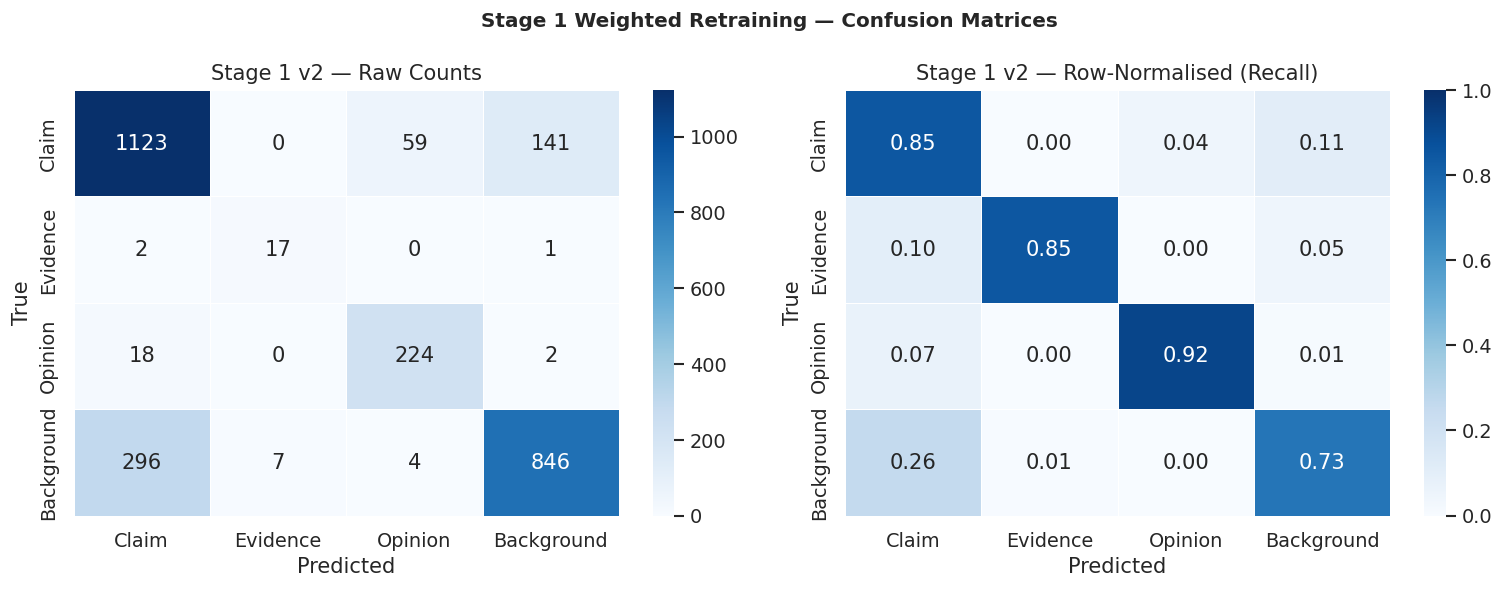

In [12]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(te_lbls, te_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, data, fmt, title in [
    (axes[0], cm,      "d",    "Raw Counts"),
    (axes[1], cm_norm, ".2f",  "Row-Normalised (Recall)"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=ax, vmin=0 if fmt==".2f" else None,
                vmax=1 if fmt==".2f" else None)
    ax.set(title=f"Stage 1 v2 — {title}", xlabel="Predicted", ylabel="True")

plt.suptitle("Stage 1 Weighted Retraining — Confusion Matrices", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage1v2_confusion_matrix.png", bbox_inches="tight")
plt.show()


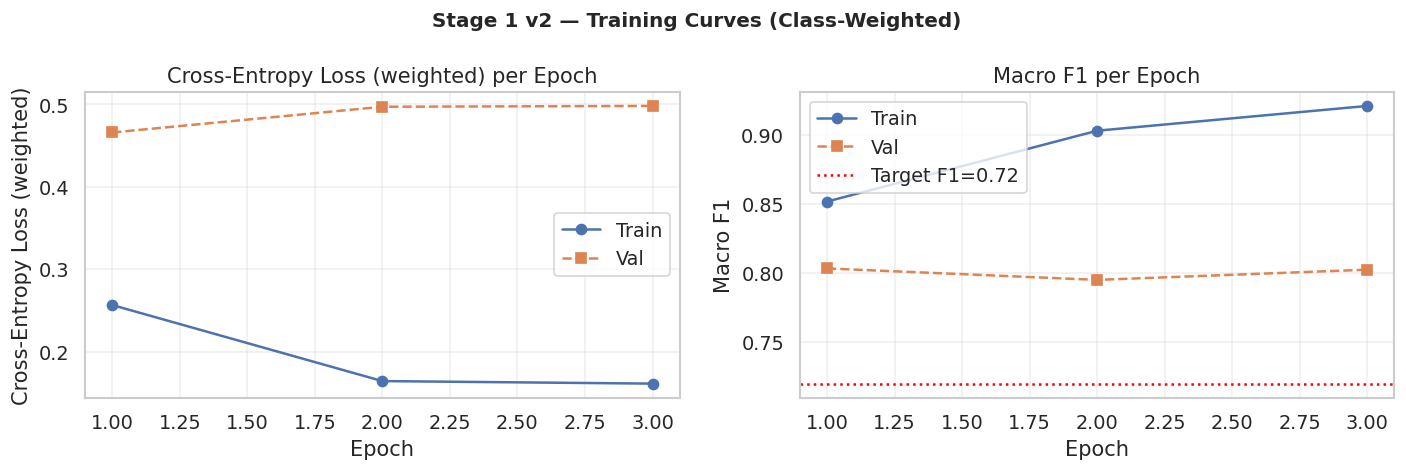

In [13]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs_x = range(1, len(history_s1["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, ylabel in [
    (axes[0], "loss", "Cross-Entropy Loss (weighted)"),
    (axes[1], "f1",   "Macro F1"),
]:
    ax.plot(epochs_x, history_s1[f"train_{metric}"], "o-", label="Train")
    ax.plot(epochs_x, history_s1[f"val_{metric}"],   "s--", label="Val")
    if metric == "f1":
        ax.axhline(0.72, color="red", linestyle=":", label="Target F1=0.72")
    ax.set(title=f"{ylabel} per Epoch", xlabel="Epoch", ylabel=ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Stage 1 v2 — Training Curves (Class-Weighted)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage1v2_training_curves.png", bbox_inches="tight")
plt.show()


---
---
# PART B · Stage 2 — Late-Fusion Transformer Citation Scorer

## Architecture Intuition

The original Stage 2 (XGBoost) only saw a **summary** of what DistilBERT thought:
four probabilities and a confidence score. It never saw the actual sentence.

The Late-Fusion architecture fixes this by passing the full `[CLS]` token
(768 dimensions) directly into the citation scorer. The `[CLS]` token is
DistilBERT's compressed representation of the entire sentence — it encodes
not just which words are present but how they relate to each other.

We concatenate this rich semantic signal with our 18 engineered features
(which encode *specific* linguistic properties the model might not capture
naturally) and feed the combined 786-dim vector into a 3-layer MLP.

```
Sentence text
      ↓
  DistilBERT
      ↓              ↓
 [CLS] (768)    epi_probs (4) ─┐
      │                        │
      └──────────┬─────────────┘
                 │  + spaCy features (12)
                 │  + sentence_length (1)
                 │  + epi_confidence (1)
                 ↓
           concat → 786-dim
                 ↓
      Linear(786→256) + LayerNorm + ReLU + Dropout(0.3)
                 ↓
      Linear(256→64)  + LayerNorm + ReLU + Dropout(0.2)
                 ↓
      Linear(64→1)    + Sigmoid
                 ↓
       citation_score ∈ [0.0, 1.0]
```

**Why LayerNorm instead of BatchNorm?**
BatchNorm computes statistics across the batch dimension and behaves differently
at train vs inference time. DistilBERT itself uses LayerNorm internally.
Mixing BatchNorm into a Transformer-based architecture creates subtle
instabilities. LayerNorm normalises across the feature dimension for each
sample independently — consistent behaviour at any batch size.


## B1 · Load WikiSQE (`citation needed` config)

We use the **`citation needed`** config from `ando55/WikiSQE_experiment`.
This maps directly to Wikipedia's `{{citation needed}}` inline template —
the exact annotation signal that a sentence lacks a reference.

The dataset provides proper `train/val/test` splits to prevent temporal leakage.
We subsample 150k total (75k positive + 75k negative) from the training split
to keep training time manageable on a local GPU.


In [14]:
print("Loading WikiSQE_experiment (citation needed config)...")
wiki_ds = load_dataset("ando55/WikiSQE_experiment", name="citation needed")
print(wiki_ds)
print("\nColumns :", wiki_ds["train"].column_names)
print("\nSample  :", wiki_ds["train"][0])


Loading WikiSQE_experiment (citation needed config)...
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 398000
    })
    val: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1000
    })
})

Columns : ['text', 'label']

Sample  : {'text': 'Two weeks later, in "Godsend," the Haitian and Claire meet again.', 'label': 0}


In [19]:
def hf_to_df(hf_split, split_name):
    df = hf_split.to_pandas().rename(columns={"text": "sentence"})
    df["split"] = split_name
    df = df.dropna(subset=["sentence"])
    df = df[df["sentence"].str.strip().str.split().str.len() >= 5]
    df["label"] = df["label"].astype(int)
    return df[["sentence", "label", "split"]].reset_index(drop=True)

train_wiki = hf_to_df(wiki_ds["train"], "train")
val_wiki   = hf_to_df(wiki_ds["val"],   "val")
test_wiki  = hf_to_df(wiki_ds["test"],  "test")

# ── Subsample 75k per class from train (150k total, balanced) ─────────────────
# Fixed: sample each class separately and concat — avoids groupby.apply()
# dropping the label column in pandas >= 2.0
TARGET_PER_CLASS = 75_000

if len(train_wiki) > TARGET_PER_CLASS * 2:
    pos_df = train_wiki[train_wiki["label"] == 1].sample(
        min(TARGET_PER_CLASS, (train_wiki["label"]==1).sum()),
        random_state=SEED
    )
    neg_df = train_wiki[train_wiki["label"] == 0].sample(
        min(TARGET_PER_CLASS, (train_wiki["label"]==0).sum()),
        random_state=SEED
    )
    train_wiki = pd.concat([pos_df, neg_df]).sample(
        frac=1, random_state=SEED
    ).reset_index(drop=True)

wiki_df = pd.concat([train_wiki, val_wiki, test_wiki], ignore_index=True)

print("WikiSQE split sizes:")
for name, df_s in [("train", train_wiki), ("val", val_wiki), ("test", test_wiki)]:
    pos = df_s["label"].sum()
    print(f"  {name:5s}: {len(df_s):>8,} rows  |  pos={pos:,}  "
          f"neg={len(df_s)-pos:,}  pos_rate={pos/len(df_s):.1%}")
# def hf_to_df(hf_split, split_name):
#     df = hf_split.to_pandas().rename(columns={"text": "sentence"})
#     df["split"] = split_name
#     df = df.dropna(subset=["sentence"])
#     df = df[df["sentence"].str.strip().str.split().str.len() >= 5]
#     return df[["sentence","label","split"]].reset_index(drop=True)

# train_wiki = hf_to_df(wiki_ds["train"], "train")
# val_wiki   = hf_to_df(wiki_ds["val"],   "val")
# test_wiki  = hf_to_df(wiki_ds["test"],  "test")

# # ── Subsample 75k per class from train (150k total, balanced) ─────────────────
# TARGET_PER_CLASS = 75_000
# if len(train_wiki) > TARGET_PER_CLASS * 2:
#     train_wiki = (
#         train_wiki
#         .groupby("label", group_keys=False)
#         .apply(lambda g: g.sample(min(TARGET_PER_CLASS, len(g)), random_state=SEED))
#         .reset_index(drop=True)
#     )

# wiki_df = pd.concat([train_wiki, val_wiki, test_wiki], ignore_index=True)
# print("WikiSQE split sizes:")
# for name, df_s in [("train", train_wiki), ("val", val_wiki), ("test", test_wiki)]:
#     pos = df_s["label"].sum()
#     print(f"  {name:5s}: {len(df_s):>8,} rows  |  pos={pos:,}  "
#           f"neg={len(df_s)-pos:,}  pos_rate={pos/len(df_s):.1%}")


WikiSQE split sizes:
  train:  150,000 rows  |  pos=75,000  neg=75,000  pos_rate=50.0%
  val  :    1,000 rows  |  pos=532  neg=468  pos_rate=53.2%
  test :    1,000 rows  |  pos=477  neg=523  pos_rate=47.7%


## B2 · WikiSQE EDA

Before training, we inspect the citation need distribution, sentence lengths,
and any obvious surface patterns. This confirms the dataset is well-suited
for our task and informs Stage 2 training decisions.


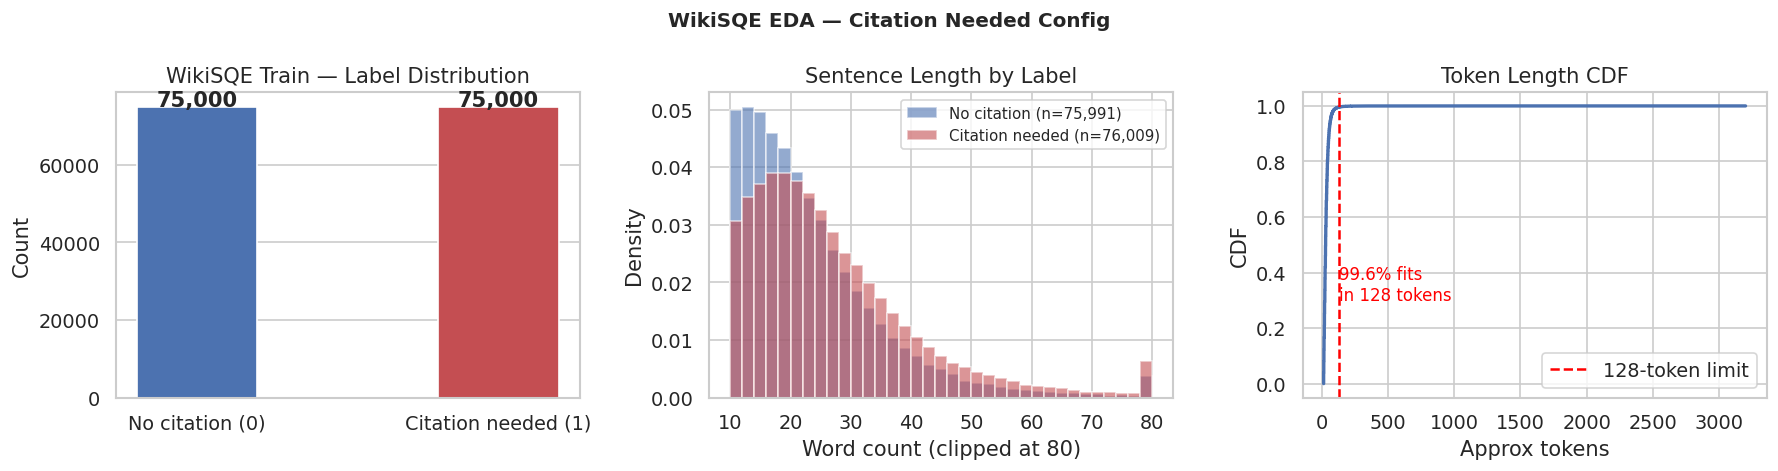


Sentence length stats by label:
       mean   std   min     max
label                          
0      23.4  19.0  10.0  2463.0
1      26.9  17.4  10.0  1808.0


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 1. Label distribution ─────────────────────────────────────────────────────
lc = train_wiki["label"].value_counts().sort_index()
axes[0].bar(["No citation (0)", "Citation needed (1)"],
            lc.values, color=["#4C72B0","#C44E52"],
            edgecolor="white", width=0.4)
for i, v in enumerate(lc.values):
    axes[0].text(i, v+100, f"{v:,}", ha="center", fontweight="bold")
axes[0].set(title="WikiSQE Train — Label Distribution", ylabel="Count")

# ── 2. Sentence length by label ───────────────────────────────────────────────
wiki_df["word_count"] = wiki_df["sentence"].str.split().str.len()
for lbl, color, name in [(0,"#4C72B0","No citation"),(1,"#C44E52","Citation needed")]:
    subset = wiki_df[wiki_df["label"]==lbl]["word_count"]
    axes[1].hist(subset.clip(upper=80), bins=35, alpha=0.6,
                 label=f"{name} (n={len(subset):,})",
                 color=color, density=True)
axes[1].set(title="Sentence Length by Label",
            xlabel="Word count (clipped at 80)", ylabel="Density")
axes[1].legend(fontsize=9)

# ── 3. Token length CDF vs 128-token limit ────────────────────────────────────
wiki_df["approx_tokens"] = (wiki_df["word_count"] * 1.3).astype(int)
sorted_t = np.sort(wiki_df["approx_tokens"].values)
cdf      = np.arange(1, len(sorted_t)+1) / len(sorted_t)
axes[2].plot(sorted_t, cdf, color="#4C72B0", linewidth=2)
axes[2].axvline(128, color="red", linestyle="--", linewidth=1.5, label="128-token limit")
pct_fits = (wiki_df["approx_tokens"] <= 128).mean() * 100
axes[2].text(132, 0.3, f"{pct_fits:.1f}% fits\nin 128 tokens",
             color="red", fontsize=10)
axes[2].set(title="Token Length CDF", xlabel="Approx tokens", ylabel="CDF")
axes[2].legend()

plt.suptitle("WikiSQE EDA — Citation Needed Config", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage2v2_wikisqe_eda.png", bbox_inches="tight")
plt.show()

print("\nSentence length stats by label:")
print(wiki_df.groupby("label")["word_count"]
      .describe()[["mean","std","min","max"]].round(1).to_string())


## B3 · spaCy Feature Extraction for WikiSQE (Cached)

In [21]:
WIKI_FEAT_CACHE = "output/stage2v2_wiki_features.csv"

if os.path.exists(WIKI_FEAT_CACHE):
    print(f"Cache found — loading {WIKI_FEAT_CACHE}")
    wiki_feat_df = pd.read_csv(WIKI_FEAT_CACHE)
    print(f"Loaded {len(wiki_feat_df):,} rows × {len(wiki_feat_df.columns)} features")
else:
    print(f"Extracting spaCy features for {len(wiki_df):,} sentences...")
    records  = []
    sentences = wiki_df["sentence"].tolist()
    total     = len(sentences)
    for batch_start in range(0, total, 256):
        batch = sentences[batch_start: batch_start+256]
        for doc in nlp.pipe(batch, disable=["ner"]):
            records.append(extract_features(str(doc)))
        if (batch_start+256) % 10000 < 256:
            done = min(batch_start+256, total)
            print(f"  {done:>8,} / {total:,}  ({done/total:.0%})", end="\r")
    print()
    wiki_feat_df = pd.DataFrame(records)
    wiki_feat_df.to_csv(WIKI_FEAT_CACHE, index=False)
    print(f"Saved → {WIKI_FEAT_CACHE}")

wiki_feat_df.head(3)


Extracting spaCy features for 152,000 sentences...
   150,016 / 152,000  (99%)
Saved → output/stage2v2_wiki_features.csv


,hedge_count,vague_quant_count,superlative_count,passive_voice,nominalization_rate,pos_noun_ratio,pos_verb_ratio,pos_adj_ratio,pos_adv_ratio,sentence_position,citation_density,para_relative_idx
0,0,1,0,1,0.021739,0.130435,0.065217,0.043478,0.043478,0.0,0,0.0
1,0,0,0,0,0.000000,0.192308,0.153846,0.076923,0.038462,0.0,0,0.0
2,0,0,0,0,0.037037,0.111111,0.074074,0.000000,0.000000,0.0,0,0.0


## B4 · Stage 1 Epistemic Inference on WikiSQE (Cached)

We run the **weighted Stage 1 checkpoint** (from Part A) on every WikiSQE
sentence. This gives us:
- 4 epistemic class probabilities (Claim / Evidence / Opinion / Background)
- 1 confidence score

These form part of the 18-dim engineered feature vector fed alongside `[CLS]`
into the MLP. The Late-Fusion model sees both the raw semantic embedding
*and* the explicit epistemic signal.

> **Why run Stage 1 if the Late-Fusion model sees [CLS] directly?**
> The `[CLS]` embedding encodes *everything* but is not explicitly trained
> to distinguish epistemic types for the citation task. The epi_probs act as
> a structured inductive bias — they tell the MLP "this sentence is 78% likely
> a Claim" in an interpretable way that `[CLS]` dimensions cannot.


In [22]:
WIKI_PRED_CACHE = "output/stage2v2_wiki_epiprobs.csv"

# Load the weighted Stage 1 model
s1_model.load_state_dict(torch.load(S1_V2_CKPT, map_location=DEVICE))
s1_model.eval()

class WikiInferenceDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len):
        self.sentences = list(sentences)
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self):  return len(self.sentences)
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx], max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0)}

if os.path.exists(WIKI_PRED_CACHE):
    print(f"Cache found — loading {WIKI_PRED_CACHE}")
    wiki_pred_df = pd.read_csv(WIKI_PRED_CACHE)
    print(f"Loaded {len(wiki_pred_df):,} rows")
else:
    print(f"Running Stage 1 inference on {len(wiki_df):,} sentences...")
    infer_ds  = WikiInferenceDataset(wiki_df["sentence"].tolist(), tokenizer, MAX_LEN)
    infer_ldr = DataLoader(infer_ds, batch_size=128, shuffle=False,
                           pin_memory=True, num_workers=2)
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(infer_ldr, desc="Epistemic inference"):
            out   = s1_model(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE),
            )
            probs = torch.softmax(out.logits, dim=-1).cpu().numpy()
            all_probs.extend(probs)

    prob_arr = np.array(all_probs)
    wiki_pred_df = pd.DataFrame(
        prob_arr, columns=[f"epi_prob_{c}" for c in CLASSES]
    )
    wiki_pred_df["epi_confidence"] = prob_arr.max(axis=1)
    wiki_pred_df["epi_pred_label"] = [ID2LABEL[i] for i in prob_arr.argmax(axis=1)]
    wiki_pred_df.to_csv(WIKI_PRED_CACHE, index=False)
    print(f"Saved → {WIKI_PRED_CACHE}")

EPI_PROB_COLS = [f"epi_prob_{c}" for c in CLASSES]
print("\nEpistemic label distribution on WikiSQE:")
print(wiki_pred_df["epi_pred_label"].value_counts().to_string())


Running Stage 1 inference on 152,000 sentences...


Epistemic inference:   0%|          | 0/1188 [00:00<?, ?it/s]

Saved → output/stage2v2_wiki_epiprobs.csv

Epistemic label distribution on WikiSQE:
epi_pred_label
Background    137574
Claim          10334
Opinion         3498
Evidence         594


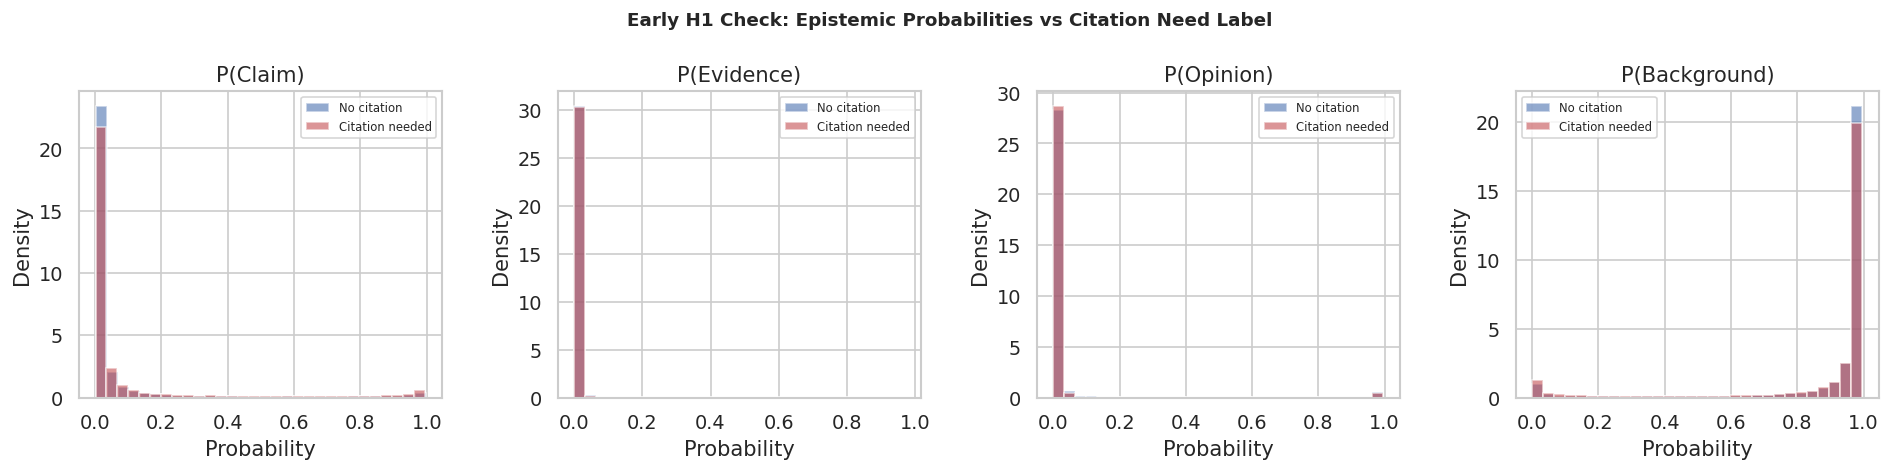


Mean epistemic probabilities by citation label:
       epi_prob_Claim  epi_prob_Evidence  epi_prob_Opinion  epi_prob_Background
label                                                                          
0               0.073              0.005             0.029                0.892
1               0.102              0.007             0.027                0.863

If H1 holds: citation_needed=1 rows should have higher epi_prob_Claim.


In [23]:
# ── Do citation-needed sentences get different epistemic labels? ───────────────
# Intuition: if H1 is correct (Claim is the key predictor), then citation_needed=1
# sentences should have higher epi_prob_Claim than citation_needed=0 sentences.
# This plot is an early empirical check of H1 BEFORE Stage 2 training.

wiki_df = wiki_df.reset_index(drop=True)
wiki_pred_df = wiki_pred_df.reset_index(drop=True)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cls in zip(axes, CLASSES):
    col = f"epi_prob_{cls}"
    for lbl, color, name in [(0,"#4C72B0","No citation"),(1,"#C44E52","Citation needed")]:
        mask = wiki_df["label"] == lbl
        ax.hist(wiki_pred_df[mask][col], bins=30, alpha=0.6,
                label=name, color=color, density=True)
    ax.set(title=f"P({cls})", xlabel="Probability", ylabel="Density")
    ax.legend(fontsize=7)

plt.suptitle("Early H1 Check: Epistemic Probabilities vs Citation Need Label",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage2v2_h1_earlycheck.png", bbox_inches="tight")
plt.show()

print("\nMean epistemic probabilities by citation label:")
prob_check = pd.concat([wiki_df["label"], wiki_pred_df[EPI_PROB_COLS]], axis=1)
print(prob_check.groupby("label")[EPI_PROB_COLS].mean().round(3).to_string())
print("\nIf H1 holds: citation_needed=1 rows should have higher epi_prob_Claim.")


## B5 · Build the 18-Dimensional Engineered Feature Vector

In [24]:
assert len(wiki_df) == len(wiki_feat_df) == len(wiki_pred_df), \
    "Row count mismatch — re-run feature extraction / inference"

wiki_feat_df = wiki_feat_df.reset_index(drop=True)
wiki_feat_df["sentence_length"] = wiki_df["sentence"].str.split().str.len()

ENG_FEATURE_COLS = FEATURE_COLS + ["sentence_length"] + EPI_PROB_COLS + ["epi_confidence"]
print(f"Engineered feature vector — {len(ENG_FEATURE_COLS)} dimensions:")
for i, c in enumerate(ENG_FEATURE_COLS, 1):
    tag = "  ← epistemic" if "epi_" in c else ""
    print(f"  {i:2d}. {c}{tag}")

feat_matrix = pd.concat([
    wiki_feat_df[FEATURE_COLS + ["sentence_length"]].reset_index(drop=True),
    wiki_pred_df[EPI_PROB_COLS + ["epi_confidence"]].reset_index(drop=True),
], axis=1).values.astype(np.float32)

labels_all = wiki_df["label"].values
splits_all = wiki_df["split"].values

print(f"\nFeature matrix shape : {feat_matrix.shape}")


Engineered feature vector — 18 dimensions:
   1. hedge_count
   2. vague_quant_count
   3. superlative_count
   4. passive_voice
   5. nominalization_rate
   6. pos_noun_ratio
   7. pos_verb_ratio
   8. pos_adj_ratio
   9. pos_adv_ratio
  10. sentence_position
  11. citation_density
  12. para_relative_idx
  13. sentence_length
  14. epi_prob_Claim  ← epistemic
  15. epi_prob_Evidence  ← epistemic
  16. epi_prob_Opinion  ← epistemic
  17. epi_prob_Background  ← epistemic
  18. epi_confidence  ← epistemic

Feature matrix shape : (152000, 18)


## B6 · Late-Fusion Model Definition

In [25]:
class LateFusionCitationScorer(nn.Module):
    """
    Late-Fusion architecture for citation need scoring.

    Two information streams:
      1. [CLS] token (768-dim) from DistilBERT — full semantic context
      2. Engineered feature vector (18-dim) — explicit epistemic + linguistic signals

    Both are concatenated and passed through a 3-layer MLP with LayerNorm
    and Dropout for regularisation.

    LayerNorm is used (not BatchNorm) because:
      - DistilBERT uses LayerNorm internally — consistent architecture
      - LayerNorm normalises per sample, not per batch — stable at any batch size
      - BatchNorm behaves differently at train vs eval — creates subtle bugs
        when fine-tuning alongside a Transformer
    """
    def __init__(self, distilbert, num_eng_features: int, dropout1=0.3, dropout2=0.2):
        super().__init__()
        self.distilbert    = distilbert
        self.num_eng_feats = num_eng_features
        cls_dim            = 768      # DistilBERT hidden size
        combined_dim       = cls_dim + num_eng_features   # 768 + 18 = 786

        self.mlp = nn.Sequential(
            # Layer 1 — from combined space to 256
            nn.Linear(combined_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout1),
            # Layer 2 — compress to 64
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout2),
            # Layer 3 — final scalar output
            nn.Linear(64, 1),
        )

    def forward(self, input_ids, attention_mask, eng_features):
        # Get [CLS] token from DistilBERT
        # hidden_states shape: (batch, seq_len, 768)
        # [CLS] is position 0
        outputs    = self.distilbert(input_ids=input_ids,
                                     attention_mask=attention_mask)
        cls_embed  = outputs.last_hidden_state[:, 0, :]   # (batch, 768)

        # Concatenate with engineered features
        combined   = torch.cat([cls_embed, eng_features], dim=1)  # (batch, 786)

        # MLP → scalar
        logit      = self.mlp(combined).squeeze(-1)   # (batch,)
        return torch.sigmoid(logit)                   # citation_score ∈ [0,1]

    def freeze_distilbert(self):
        """Freeze ALL DistilBERT parameters (Phase 1)."""
        for param in self.distilbert.parameters():
            param.requires_grad = False
        print("DistilBERT frozen — only MLP trains.")

    def unfreeze_top_layers(self, n_layers=2):
        """Unfreeze the top N transformer layers + pooler (Phase 2)."""
        # DistilBERT has 6 transformer layers (0–5)
        # We unfreeze the last n_layers
        unfreeze_from = 6 - n_layers
        for i, layer in enumerate(self.distilbert.transformer.layer):
            if i >= unfreeze_from:
                for param in layer.parameters():
                    param.requires_grad = True
        print(f"Unfrozen: last {n_layers} transformer layers. MLP continues training.")

    def unfreeze_all(self):
        """Unfreeze everything (Phase 3)."""
        for param in self.distilbert.parameters():
            param.requires_grad = True
        print("All DistilBERT parameters unfrozen.")

    def trainable_params(self):
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        return n, total

# ── Instantiate ────────────────────────────────────────────────────────────────
distilbert_backbone = DistilBertModel.from_pretrained(MODEL_NAME)
# Load Stage 1 weights into the backbone
# DistilBertForSequenceClassification wraps DistilBertModel — we extract the base
s1_state = torch.load(S1_V2_CKPT, map_location="cpu")
backbone_state = {
    k.replace("distilbert.", ""): v
    for k, v in s1_state.items()
    if k.startswith("distilbert.")
}
distilbert_backbone.load_state_dict(backbone_state, strict=False)
print("Stage 1 backbone weights loaded into Late-Fusion model.")

lf_model = LateFusionCitationScorer(
    distilbert=distilbert_backbone,
    num_eng_features=len(ENG_FEATURE_COLS),
).to(DEVICE)

trainable, total = lf_model.trainable_params()
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Stage 1 backbone weights loaded into Late-Fusion model.
Total parameters     : 66,581,505
Trainable parameters : 66,581,505


## B7 · Late-Fusion Dataset & DataLoaders

In [26]:
class LateFusionDataset(Dataset):
    """
    Returns tokenised sentence + engineered feature vector + citation label.
    The engineered features are stored as float32 tensors to avoid repeated
    conversion during training.
    """
    def __init__(self, sentences, eng_features, labels, tokenizer, max_len):
        self.sentences    = list(sentences)
        self.eng_features = torch.tensor(eng_features, dtype=torch.float32)
        self.labels       = torch.tensor(list(labels),  dtype=torch.float32)
        self.tokenizer    = tokenizer
        self.max_len      = max_len

    def __len__(self):  return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.sentences[idx], max_length=self.max_len,
            padding="max_length", truncation=True, return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "eng_features":   self.eng_features[idx],
            "label":          self.labels[idx],
        }

# ── Split masks ────────────────────────────────────────────────────────────────
tr_mask = splits_all == "train"
va_mask = splits_all == "val"
te_mask = splits_all == "test"

LF_BATCH = 32

lf_train = LateFusionDataset(
    wiki_df.loc[tr_mask, "sentence"].tolist(),
    feat_matrix[tr_mask], labels_all[tr_mask], tokenizer, MAX_LEN
)
lf_val = LateFusionDataset(
    wiki_df.loc[va_mask, "sentence"].tolist(),
    feat_matrix[va_mask], labels_all[va_mask], tokenizer, MAX_LEN
)
lf_test = LateFusionDataset(
    wiki_df.loc[te_mask, "sentence"].tolist(),
    feat_matrix[te_mask], labels_all[te_mask], tokenizer, MAX_LEN
)

lf_train_ldr = DataLoader(lf_train, batch_size=LF_BATCH, shuffle=True,  pin_memory=True, num_workers=2)
lf_val_ldr   = DataLoader(lf_val,   batch_size=LF_BATCH, shuffle=False, pin_memory=True, num_workers=2)
lf_test_ldr  = DataLoader(lf_test,  batch_size=LF_BATCH, shuffle=False, pin_memory=True, num_workers=2)

print(f"Train batches : {len(lf_train_ldr):,}")
print(f"Val batches   : {len(lf_val_ldr):,}")
print(f"Test batches  : {len(lf_test_ldr):,}")


Train batches : 4,688
Val batches   : 32
Test batches  : 32


## B8 · Training Infrastructure

In [27]:
def run_lf_epoch(model, loader, optimizer, scheduler, device, train=True):
    """Single training or evaluation pass for the Late-Fusion model."""
    model.train() if train else model.eval()
    total_loss, all_scores, all_labels = 0.0, [], []
    loss_fn = nn.BCELoss()

    pbar = tqdm(loader, desc="Train" if train else "Eval ", leave=False)
    for step, batch in enumerate(pbar):
        ids    = batch["input_ids"].to(device)
        mask   = batch["attention_mask"].to(device)
        feats  = batch["eng_features"].to(device)
        lbls   = batch["label"].to(device)

        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            scores = model(ids, mask, feats)
            loss   = loss_fn(scores, lbls)

        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if scheduler:
                scheduler.step()

        total_loss  += loss.item()
        all_scores.extend(scores.detach().cpu().numpy())
        all_labels.extend(lbls.cpu().numpy())

        if (step+1) % 50 == 0:
            pbar.set_postfix({"loss": f"{total_loss/(step+1):.4f}"})

    avg_loss  = total_loss / len(loader)
    scores_np = np.array(all_scores)
    labels_np = np.array(all_labels)
    preds_np  = (scores_np >= 0.5).astype(int)
    auc       = roc_auc_score(labels_np, scores_np) if len(np.unique(labels_np))>1 else 0.0
    f1        = f1_score(labels_np, preds_np, zero_division=0)
    return avg_loss, auc, f1, scores_np, labels_np

def make_optimizer_scheduler(model, lr, total_steps, warmup_frac=0.1):
    opt = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=0.01
    )
    sch = get_linear_schedule_with_warmup(
        opt,
        num_warmup_steps=int(warmup_frac * total_steps),
        num_training_steps=total_steps,
    )
    return opt, sch

def log_phase_header(phase_name, lr, trainable):
    print("\n" + "═"*75)
    print(f"  {phase_name}")
    print(f"  Learning rate   : {lr}")
    print(f"  Trainable params: {trainable:,}")
    print("═"*75)
    print(f"  {'EPOCH':^5} {'TR LOSS':^10} {'TR AUC':^8} {'TR F1':^7} "
          f"{'VL LOSS':^10} {'VL AUC':^8} {'VL F1':^7} {'TIME':^7} {'':^8}")
    print("─"*75)


## B9 · Phase 1 — MLP Head Only (DistilBERT Frozen)

**Why start with DistilBERT frozen?**

The MLP head is randomly initialised. If we immediately allow gradients to
flow through all 66M DistilBERT parameters, the random head produces large,
noisy gradients that corrupt the transformer weights before the head has
learned anything useful. This is analogous to trying to teach someone a new
skill while simultaneously asking them to unlearn everything they know.

Phase 1 freezes DistilBERT entirely and only trains the ~200k MLP parameters.
Within 2 epochs, the MLP learns a reasonable mapping from the 786-dim vector
to citation need. Only then do we cautiously unfreeze the transformer.


In [28]:
PHASE1_EPOCHS = 2
PHASE1_LR     = 1e-3
PHASE1_CKPT   = "output/stage2v2_best_phase1.pt"

lf_model.freeze_distilbert()
trainable, total = lf_model.trainable_params()

total_steps_p1 = len(lf_train_ldr) * PHASE1_EPOCHS
opt_p1, sch_p1 = make_optimizer_scheduler(lf_model, PHASE1_LR, total_steps_p1)

log_phase_header("Phase 1 — MLP Head Only (DistilBERT Frozen)", PHASE1_LR, trainable)

best_auc_p1 = 0.0
hist_p1     = {k:[] for k in ["tr_loss","tr_auc","vl_loss","vl_auc"]}

for epoch in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_auc, tr_f1, _, _ = run_lf_epoch(lf_model, lf_train_ldr, opt_p1, sch_p1, DEVICE)
    vl_loss, vl_auc, vl_f1, _, _ = run_lf_epoch(lf_model, lf_val_ldr,   opt_p1, None,   DEVICE, train=False)
    elapsed = time.time() - t0

    for k, v in zip(["tr_loss","tr_auc","vl_loss","vl_auc"],
                    [tr_loss, tr_auc, vl_loss, vl_auc]):
        hist_p1[k].append(v)

    tag = ""
    if vl_auc > best_auc_p1:
        best_auc_p1 = vl_auc
        torch.save(lf_model.state_dict(), PHASE1_CKPT)
        tag = "✓ saved"

    print(f"  {epoch:^5}  {tr_loss:^10.4f} {tr_auc:^8.4f} {tr_f1:^7.4f} "
          f"{vl_loss:^10.4f} {vl_auc:^8.4f} {vl_f1:^7.4f} {elapsed:^6.1f}s  {tag}")

print(f"\nPhase 1 best Val AUC: {best_auc_p1:.4f}")


DistilBERT frozen — only MLP trains.

═══════════════════════════════════════════════════════════════════════════
  Phase 1 — MLP Head Only (DistilBERT Frozen)
  Learning rate   : 0.001
  Trainable params: 218,625
═══════════════════════════════════════════════════════════════════════════
  EPOCH  TR LOSS    TR AUC   TR F1   VL LOSS    VL AUC   VL F1   TIME           
───────────────────────────────────────────────────────────────────────────


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    1      0.6505    0.6609  0.6356    0.6282    0.6911  0.7092  188.3 s  ✓ saved


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    2      0.6307    0.6922  0.6555    0.6190    0.7037  0.6866  199.8 s  ✓ saved

Phase 1 best Val AUC: 0.7037


## B10 · Phase 2 — Unfreeze Top 2 Transformer Layers

Now that the MLP head is stable, we carefully unfreeze the **last 2 of 6**
DistilBERT transformer layers. These top layers encode the most task-specific
representations — they are the layers most likely to benefit from adapting
to the citation task. The bottom 4 layers encode general linguistic knowledge
(syntax, morphology) that transfers well from both pretraining and Stage 1 —
we leave them frozen.

The learning rate drops significantly (2e-5 vs 1e-3) to prevent the
now-stable transformer weights from changing too aggressively.


In [29]:
PHASE2_EPOCHS = 3
PHASE2_LR     = 2e-5
PHASE2_CKPT   = "output/stage2v2_best_phase2.pt"

lf_model.load_state_dict(torch.load(PHASE1_CKPT, map_location=DEVICE))
lf_model.unfreeze_top_layers(n_layers=2)
trainable, _ = lf_model.trainable_params()

total_steps_p2 = len(lf_train_ldr) * PHASE2_EPOCHS
opt_p2, sch_p2 = make_optimizer_scheduler(lf_model, PHASE2_LR, total_steps_p2)

log_phase_header("Phase 2 — Top 2 Transformer Layers Unfrozen", PHASE2_LR, trainable)

best_auc_p2 = 0.0
hist_p2     = {k:[] for k in ["tr_loss","tr_auc","vl_loss","vl_auc"]}
no_improve  = 0
PATIENCE_P2 = 2

for epoch in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_auc, tr_f1, _, _ = run_lf_epoch(lf_model, lf_train_ldr, opt_p2, sch_p2, DEVICE)
    vl_loss, vl_auc, vl_f1, _, _ = run_lf_epoch(lf_model, lf_val_ldr,   opt_p2, None,   DEVICE, train=False)
    elapsed = time.time() - t0

    for k, v in zip(["tr_loss","tr_auc","vl_loss","vl_auc"],
                    [tr_loss, tr_auc, vl_loss, vl_auc]):
        hist_p2[k].append(v)

    tag = ""
    if vl_auc > best_auc_p2:
        best_auc_p2 = vl_auc
        torch.save(lf_model.state_dict(), PHASE2_CKPT)
        tag = "✓ saved"
        no_improve = 0
    else:
        no_improve += 1

    print(f"  {epoch:^5}  {tr_loss:^10.4f} {tr_auc:^8.4f} {tr_f1:^7.4f} "
          f"{vl_loss:^10.4f} {vl_auc:^8.4f} {vl_f1:^7.4f} {elapsed:^6.1f}s  {tag}")

    if no_improve >= PATIENCE_P2:
        print(f"Early stopping (Phase 2).")
        break

print(f"\nPhase 2 best Val AUC: {best_auc_p2:.4f}")


Unfrozen: last 2 transformer layers. MLP continues training.

═══════════════════════════════════════════════════════════════════════════
  Phase 2 — Top 2 Transformer Layers Unfrozen
  Learning rate   : 2e-05
  Trainable params: 14,394,369
═══════════════════════════════════════════════════════════════════════════
  EPOCH  TR LOSS    TR AUC   TR F1   VL LOSS    VL AUC   VL F1   TIME           
───────────────────────────────────────────────────────────────────────────


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    1      0.6096    0.7216  0.6694    0.5863    0.7521  0.6986  315.4 s  ✓ saved


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    2      0.5810    0.7557  0.6884    0.5787    0.7544  0.7243  326.5 s  ✓ saved


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    3      0.5642    0.7739  0.7027    0.5780    0.7546  0.7024  326.9 s  ✓ saved

Phase 2 best Val AUC: 0.7546


## B11 · Phase 3 — Full Model Fine-Tuning

The final phase unfreezes all DistilBERT parameters for conservative global
tuning. The learning rate (5e-6) is extremely small — this is 400x smaller
than Phase 1. We are making micro-adjustments, not relearning anything.

The goal is to let the lower transformer layers (which encode syntax and general
language patterns) make small adaptations to the citation task domain.
Early stopping with patience=2 prevents overfitting.


In [30]:
PHASE3_EPOCHS = 2
PHASE3_LR     = 5e-6
PHASE3_CKPT   = "output/stage2v2_best_final.pt"

lf_model.load_state_dict(torch.load(PHASE2_CKPT, map_location=DEVICE))
lf_model.unfreeze_all()
trainable, total = lf_model.trainable_params()

total_steps_p3 = len(lf_train_ldr) * PHASE3_EPOCHS
opt_p3, sch_p3 = make_optimizer_scheduler(lf_model, PHASE3_LR, total_steps_p3, warmup_frac=0.05)

log_phase_header("Phase 3 — Full Model (All Layers Unfrozen)", PHASE3_LR, trainable)

best_auc_p3 = 0.0
hist_p3     = {k:[] for k in ["tr_loss","tr_auc","vl_loss","vl_auc"]}
no_improve  = 0
PATIENCE_P3 = 1

for epoch in range(1, PHASE3_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_auc, tr_f1, _, _ = run_lf_epoch(lf_model, lf_train_ldr, opt_p3, sch_p3, DEVICE)
    vl_loss, vl_auc, vl_f1, _, _ = run_lf_epoch(lf_model, lf_val_ldr,   opt_p3, None,   DEVICE, train=False)
    elapsed = time.time() - t0

    for k, v in zip(["tr_loss","tr_auc","vl_loss","vl_auc"],
                    [tr_loss, tr_auc, vl_loss, vl_auc]):
        hist_p3[k].append(v)

    tag = ""
    if vl_auc > best_auc_p3:
        best_auc_p3 = vl_auc
        torch.save(lf_model.state_dict(), PHASE3_CKPT)
        tag = "✓ saved"
        no_improve = 0
    else:
        no_improve += 1

    print(f"  {epoch:^5}  {tr_loss:^10.4f} {tr_auc:^8.4f} {tr_f1:^7.4f} "
          f"{vl_loss:^10.4f} {vl_auc:^8.4f} {vl_f1:^7.4f} {elapsed:^6.1f}s  {tag}")

    if no_improve >= PATIENCE_P3:
        print(f"Early stopping (Phase 3).")
        break

print(f"\nPhase 3 best Val AUC: {best_auc_p3:.4f}")


All DistilBERT parameters unfrozen.

═══════════════════════════════════════════════════════════════════════════
  Phase 3 — Full Model (All Layers Unfrozen)
  Learning rate   : 5e-06
  Trainable params: 66,581,505
═══════════════════════════════════════════════════════════════════════════
  EPOCH  TR LOSS    TR AUC   TR F1   VL LOSS    VL AUC   VL F1   TIME           
───────────────────────────────────────────────────────────────────────────


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    1      0.5584    0.7800  0.7076    0.5760    0.7580  0.7060  656.0 s  ✓ saved


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/32 [00:00<?, ?it/s]

    2      0.5308    0.8073  0.7324    0.5834    0.7594  0.7056  803.1 s  ✓ saved

Phase 3 best Val AUC: 0.7594


## B12 · Combined Training Curves — All Three Phases

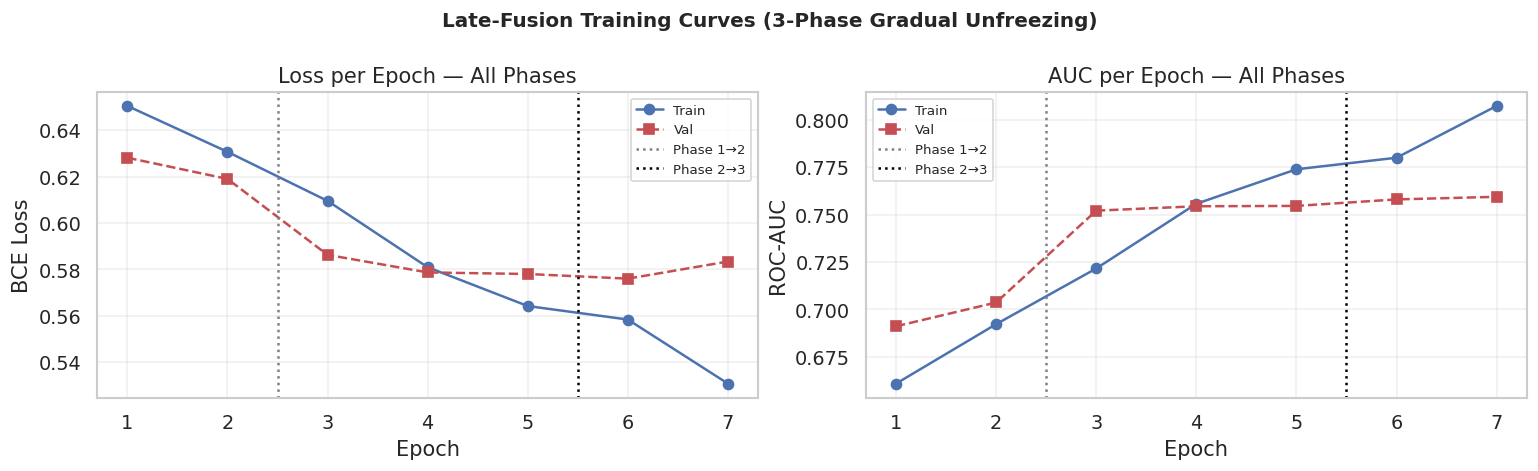

In [31]:
# Concatenate history across phases with phase boundary markers
all_tr_loss = hist_p1["tr_loss"] + hist_p2["tr_loss"] + hist_p3["tr_loss"]
all_vl_loss = hist_p1["vl_loss"] + hist_p2["vl_loss"] + hist_p3["vl_loss"]
all_tr_auc  = hist_p1["tr_auc"]  + hist_p2["tr_auc"]  + hist_p3["tr_auc"]
all_vl_auc  = hist_p1["vl_auc"]  + hist_p2["vl_auc"]  + hist_p3["vl_auc"]

xs     = list(range(1, len(all_tr_loss)+1))
p1_end = PHASE1_EPOCHS
p2_end = PHASE1_EPOCHS + len(hist_p2["tr_loss"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, tr, vl, title, ylabel in [
    (axes[0], all_tr_loss, all_vl_loss, "Loss", "BCE Loss"),
    (axes[1], all_tr_auc,  all_vl_auc,  "AUC",  "ROC-AUC"),
]:
    ax.plot(xs, tr, "o-", label="Train", color="#4C72B0")
    ax.plot(xs, vl, "s--",label="Val",   color="#C44E52")
    ax.axvline(p1_end+0.5, color="gray", linestyle=":", linewidth=1.5,
               label="Phase 1→2")
    ax.axvline(p2_end+0.5, color="black", linestyle=":", linewidth=1.5,
               label="Phase 2→3")
    ax.set(title=f"{title} per Epoch — All Phases",
           xlabel="Epoch", ylabel=ylabel)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Late-Fusion Training Curves (3-Phase Gradual Unfreezing)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage2v2_training_curves.png", bbox_inches="tight")
plt.show()


## B13 · Final Test Set Evaluation

In [32]:
lf_model.load_state_dict(torch.load(PHASE3_CKPT, map_location=DEVICE))

te_loss, te_auc, te_f1, te_scores, te_labels = run_lf_epoch(
    lf_model, lf_test_ldr, None, None, DEVICE, train=False
)
te_preds = (te_scores >= 0.5).astype(int)

print("=" * 60)
print("  LATE-FUSION STAGE 2 — TEST SET RESULTS")
print("=" * 60)
print(f"  ROC-AUC           : {te_auc:.4f}")
print(f"  Binary F1         : {te_f1:.4f}")
print(f"  Accuracy          : {accuracy_score(te_labels, te_preds):.4f}")
print(f"  Avg. Precision    : {average_precision_score(te_labels, te_scores):.4f}")
print(f"  Brier Score       : {brier_score_loss(te_labels, te_scores):.4f}")
print("=" * 60)
print("\nPer-class report:")
print(classification_report(te_labels, te_preds,
                             target_names=["No citation","Citation needed"]))


Eval :   0%|          | 0/32 [00:00<?, ?it/s]

  LATE-FUSION STAGE 2 — TEST SET RESULTS
  ROC-AUC           : 0.7456
  Binary F1         : 0.6840
  Accuracy          : 0.6840
  Avg. Precision    : 0.7303
  Brier Score       : 0.2092

Per-class report:
                 precision    recall  f1-score   support

    No citation       0.72      0.65      0.68       523
Citation needed       0.65      0.72      0.68       477

       accuracy                           0.68      1000
      macro avg       0.69      0.69      0.68      1000
   weighted avg       0.69      0.68      0.68      1000



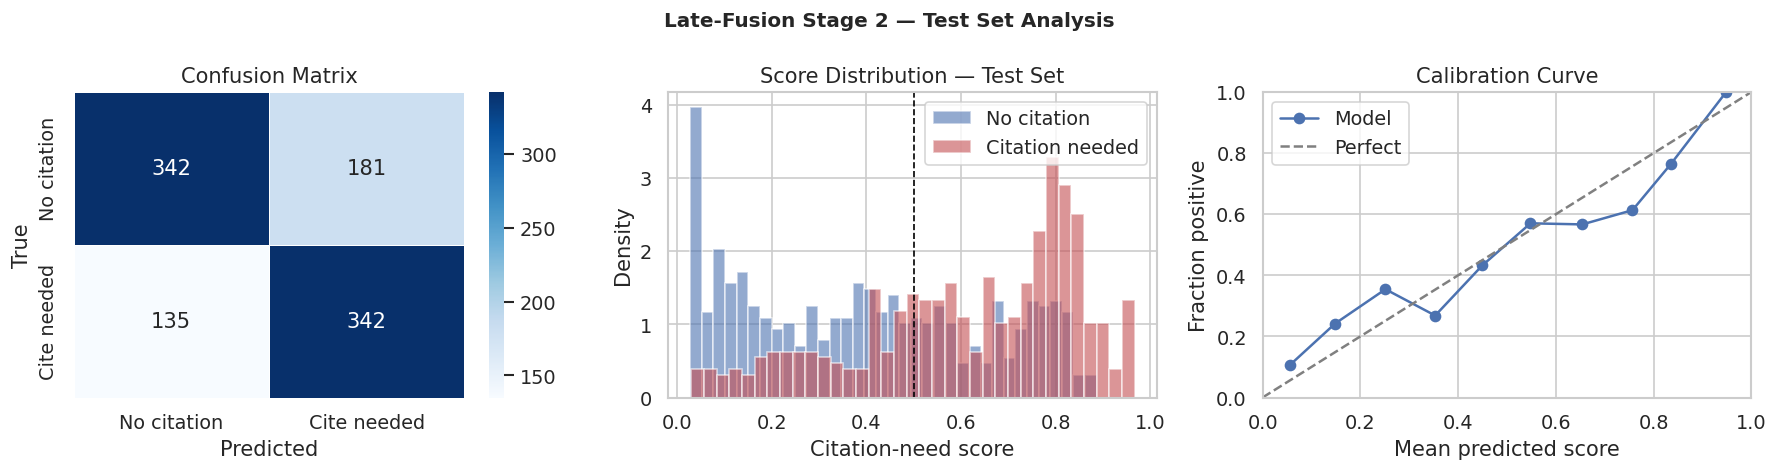

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── 1. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(te_labels, te_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No citation","Cite needed"],
            yticklabels=["No citation","Cite needed"],
            linewidths=0.5, ax=axes[0])
axes[0].set(title="Confusion Matrix", xlabel="Predicted", ylabel="True")

# ── 2. Score distribution ─────────────────────────────────────────────────────
for lbl, color, name in [(0,"#4C72B0","No citation"),(1,"#C44E52","Citation needed")]:
    mask = te_labels == lbl
    axes[1].hist(te_scores[mask], bins=35, alpha=0.6,
                 label=name, color=color, density=True)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1)
axes[1].set(title="Score Distribution — Test Set",
            xlabel="Citation-need score", ylabel="Density")
axes[1].legend()

# ── 3. Calibration curve ──────────────────────────────────────────────────────
frac_pos, mean_pred = calibration_curve(te_labels, te_scores, n_bins=10)
axes[2].plot(mean_pred, frac_pos, "o-", label="Model", color="#4C72B0")
axes[2].plot([0,1],[0,1],"--", color="gray", label="Perfect")
axes[2].set(title="Calibration Curve",
            xlabel="Mean predicted score", ylabel="Fraction positive",
            xlim=(0,1), ylim=(0,1))
axes[2].legend()

plt.suptitle("Late-Fusion Stage 2 — Test Set Analysis", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage2v2_test_analysis.png", bbox_inches="tight")
plt.show()


## B14 · SHAP Explainability — Track 1: Engineered Features

**What SHAP tells us and why it answers RQ2**

SHAP (SHapley Additive exPlanations) assigns each feature a value representing
its contribution to a specific prediction. The mean absolute SHAP value across
many predictions tells us how important each feature is *on average*.

For RQ2 we need to know: *"Is epi_prob_Claim a more powerful predictor of
citation need than surface features like sentence_length?"*

**The trick for Transformers:** We cannot run standard SHAP over all 786
dimensions — 768 of them are `[CLS]` dimensions with no human-interpretable
meaning. Instead, we freeze the CLS path and run `KernelExplainer` over the
**18 engineered features only**, treating the CLS embedding as a fixed context.
This gives clean, interpretable feature-level SHAP values at modest compute cost.


In [34]:
# ── Wrapper: fixed [CLS], variable engineered features ────────────────────────
# We freeze the model and extract [CLS] embeddings for the background/test sets.
# Then KernelExplainer calls the wrapper with different feature vectors while
# the CLS embedding stays constant per sample.
# For a global importance chart we average across samples.

lf_model.eval()
lf_model.distilbert.requires_grad_(False)

def get_cls_embeddings(sentences, batch_size=64):
    """Extract [CLS] embeddings for a list of sentences."""
    dataset = WikiInferenceDataset(sentences, tokenizer, MAX_LEN)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    embeddings = []
    with torch.no_grad():
        for batch in loader:
            out = lf_model.distilbert(
                input_ids      = batch["input_ids"].to(DEVICE),
                attention_mask = batch["attention_mask"].to(DEVICE),
            )
            embeddings.append(out.last_hidden_state[:, 0, :].cpu())
    return torch.cat(embeddings, dim=0)

# Use test set for SHAP (1k samples — fast)
SHAP_N = min(200, int(te_mask.sum()))
shap_idx = np.random.default_rng(SEED).choice(
    int(te_mask.sum()), size=SHAP_N, replace=False
)
shap_sentences = wiki_df.loc[te_mask, "sentence"].iloc[shap_idx].tolist()
shap_feats     = feat_matrix[te_mask][shap_idx]
shap_cls       = get_cls_embeddings(shap_sentences)

print(f"SHAP sample: {SHAP_N} test sentences")
print(f"CLS embeddings shape: {shap_cls.shape}")

# Background: 100-sample summary for KernelExplainer
bg_idx  = np.random.default_rng(SEED+1).choice(SHAP_N, size=100, replace=False)
bg_feats = shap_feats[bg_idx]
bg_cls   = shap_cls[bg_idx]

def lf_predict_from_feats(eng_feats_np):
    """
    Wrapper for KernelExplainer.
    Takes a numpy array of engineered features (N × 18).
    For each row, uses the *average* CLS embedding as context.
    Returns predicted citation scores (N,).
    """
    avg_cls = shap_cls.mean(dim=0, keepdim=True)  # (1, 768)
    avg_cls_batch = avg_cls.repeat(len(eng_feats_np), 1).to(DEVICE)  # (N, 768)
    feats_tensor  = torch.tensor(eng_feats_np, dtype=torch.float32).to(DEVICE)
    combined      = torch.cat([avg_cls_batch, feats_tensor], dim=1)

    with torch.no_grad():
        logits = lf_model.mlp(combined).squeeze(-1)
        scores = torch.sigmoid(logits).cpu().numpy()
    return scores

print("\nRunning KernelExplainer on 18 engineered features...")
print("(This uses average [CLS] as context — isolates the engineered feature contribution)")
explainer   = shap.KernelExplainer(lf_predict_from_feats, bg_feats)
shap_values = explainer.shap_values(shap_feats, nsamples=200, l1_reg="num_features(10)")
print(f"SHAP values shape: {shap_values.shape}")


SHAP sample: 200 test sentences
CLS embeddings shape: torch.Size([200, 768])

Running KernelExplainer on 18 engineered features...
(This uses average [CLS] as context — isolates the engineered feature contribution)


  0%|          | 0/200 [00:00<?, ?it/s]

SHAP values shape: (200, 18)


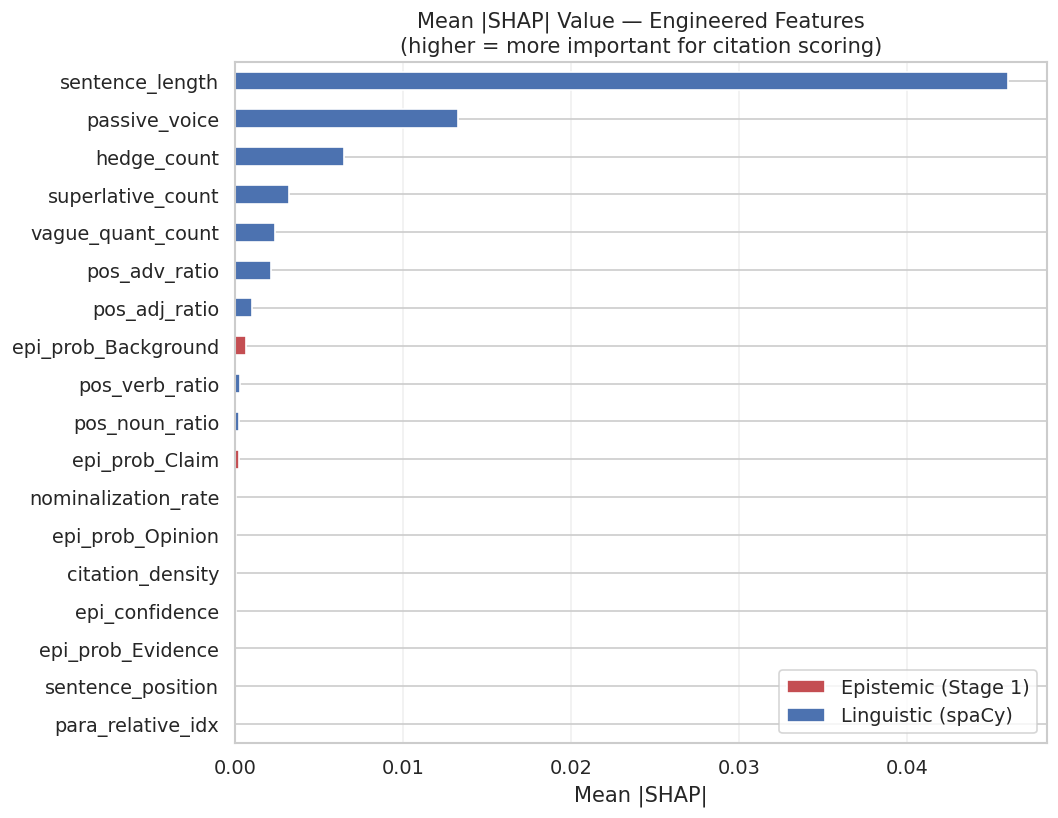

Top 5 features by mean |SHAP|:
  1. sentence_length                0.04598
  2. passive_voice                  0.01324
  3. hedge_count                    0.00647
  4. superlative_count              0.00323
  5. vague_quant_count              0.00235

epi_prob_Claim rank : 11
All epistemic ranks : [8, 11, 13, 15, 16]

→ H1 needs nuanced discussion — see report limitations.


In [35]:
# ── Bar chart — mean |SHAP| per feature ──────────────────────────────────────
mean_abs = np.abs(shap_values).mean(axis=0)
feat_imp  = pd.Series(mean_abs, index=ENG_FEATURE_COLS).sort_values(ascending=True)

colors = ["#C44E52" if "epi_" in f else "#4C72B0" for f in feat_imp.index]

fig, ax = plt.subplots(figsize=(9, 7))
feat_imp.plot(kind="barh", ax=ax, color=colors, edgecolor="white")
patches = [
    mpatches.Patch(facecolor="#C44E52", label="Epistemic (Stage 1)"),
    mpatches.Patch(facecolor="#4C72B0", label="Linguistic (spaCy)"),
]
ax.legend(handles=patches, loc="lower right")
ax.set(title="Mean |SHAP| Value — Engineered Features\n"
             "(higher = more important for citation scoring)",
       xlabel="Mean |SHAP|")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("output/stage2v2_shap_bar.png", bbox_inches="tight")
plt.show()

# ── H1 test ───────────────────────────────────────────────────────────────────
ranked = feat_imp.sort_values(ascending=False)
print("Top 5 features by mean |SHAP|:")
for rank, (feat, val) in enumerate(ranked.head(5).items(), 1):
    tag = "  ← epistemic" if "epi_" in feat else ""
    print(f"  {rank}. {feat:<30} {val:.5f}{tag}")

claim_rank = list(ranked.index).index("epi_prob_Claim") + 1
epi_ranks  = [i+1 for i, f in enumerate(ranked.index) if "epi_" in f]
print(f"\nepi_prob_Claim rank : {claim_rank}")
print(f"All epistemic ranks : {epi_ranks}")
if claim_rank <= 3:
    print("\n→ H1 SUPPORTED: epistemic type is among the top predictors.")
else:
    print("\n→ H1 needs nuanced discussion — see report limitations.")


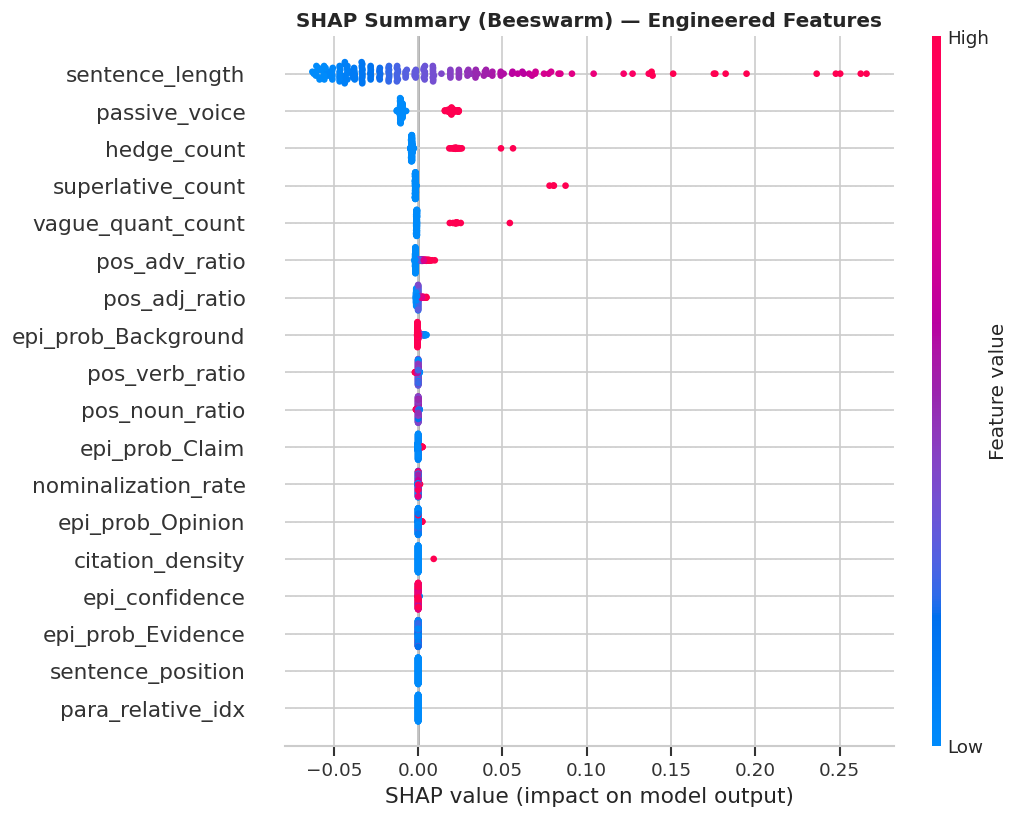

Beeswarm shows direction: red=high feature value, blue=low.
Points right of centre = pushed score TOWARD citation needed.


In [36]:
# ── SHAP beeswarm summary plot ─────────────────────────────────────────────────
plt.figure(figsize=(9, 7))
shap.summary_plot(
    shap_values, shap_feats,
    feature_names=ENG_FEATURE_COLS,
    show=False, plot_size=None,
)
plt.title("SHAP Summary (Beeswarm) — Engineered Features",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("output/stage2v2_shap_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()
print("Beeswarm shows direction: red=high feature value, blue=low.")
print("Points right of centre = pushed score TOWARD citation needed.")


## B15 · SHAP Explainability — Track 2: Integrated Gradients (Token Attribution)

**What Integrated Gradients show**

While Track 1 tells us *which engineered features matter*, Track 2 tells us
*which words in the sentence* drove the citation score. Integrated Gradients
(Sundararajan et al., 2017) computes the path integral of gradients from a
baseline (empty/padded sentence) to the actual input, attributing the score
change to each input token.

This is used for the qualitative analysis section of the report — showing
a reviewer a specific sentence and saying *"the model flagged this sentence
because of the words 'suggests' and 'may'"* is much more compelling than
a number alone.

We use `captum` (PyTorch's interpretability library) which implements
Integrated Gradients natively for embedding-based models.


In [38]:
try:
    from captum.attr import IntegratedGradients, visualization as viz
    CAPTUM_AVAILABLE = True
    print("captum available — running Integrated Gradients.")
except ImportError:
    CAPTUM_AVAILABLE = False
    print("captum not installed. Run: pip install captum")
    print("Skipping Track 2. Install captum and re-run this cell.")


captum available — running Integrated Gradients.


In [44]:
# if CAPTUM_AVAILABLE:
#     def forward_with_embeddings(embeddings, attention_mask, eng_features):
#         # DistilBERT's Transformer block signature:
#         # forward(hidden_states, attn_mask, head_mask, ...)
#         # and returns a tuple — first element is the hidden states
#         transformer_out = lf_model.distilbert.transformer(
#             hidden_states        = embeddings,
#             attn_mask            = attention_mask,
#             head_mask            = [None] * 6,
#             output_attentions    = False,
#             output_hidden_states = False,
#         )
#         # transformer_out is a tuple; [0] is the last hidden state (batch, seq, 768)
#         cls_embed = transformer_out[0][:, 0, :]
#         combined  = torch.cat([cls_embed, eng_features], dim=1)
#         return torch.sigmoid(lf_model.mlp(combined).squeeze(-1))

#     demo_sentences = [
#         "Studies show that cloning remains an experimental technology with an extremely high failure rate.",
#         "Water boils at 100 degrees Celsius at sea level.",
#         "Some researchers suggest that dark matter may account for most of the universe's mass.",
#         "I think this approach is probably the best one available.",
#         "According to the American Civil Liberties Union, the state will spend $3.5 million.",
#         "The population of the city has grown significantly in the past decade.",
#         "Evidence suggests that requiring school uniforms may increase graduation rates.",
#         "He was born in 1985 and later moved to London.",
#     ]

#     lf_model.eval()
#     ig = IntegratedGradients(forward_with_embeddings)
#     results_ig = []

#     for sent in demo_sentences:
#         enc  = tokenizer(sent, return_tensors="pt", max_length=MAX_LEN,
#                          padding="max_length", truncation=True)
#         ids  = enc["input_ids"].to(DEVICE)
#         mask = enc["attention_mask"].to(DEVICE)

#         with torch.no_grad():
#             embeddings = lf_model.distilbert.embeddings(ids)

#         baseline = torch.zeros_like(embeddings)
#         eng_feat = torch.zeros(1, len(ENG_FEATURE_COLS)).to(DEVICE)

#         # attention_mask for transformer: (batch, 1, 1, seq_len) float
#         attn_mask_4d = mask.unsqueeze(1).unsqueeze(2).float()

#         attributions, _ = ig.attribute(
#             embeddings, baseline,
#             additional_forward_args=(attn_mask_4d, eng_feat),
#             n_steps=50,
#             return_convergence_delta=True,
#         )

#         token_attr = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
#         tokens     = tokenizer.convert_ids_to_tokens(ids[0])
#         seq_len    = int(mask[0].sum().item())
#         tokens     = tokens[:seq_len]
#         token_attr = token_attr[:seq_len]

#         with torch.no_grad():
#             spacy_feats = extract_features(sent)
#             epi_feats   = [spacy_feats[k] for k in FEATURE_COLS]
#             feats_full  = torch.tensor(
#                 epi_feats + [len(sent.split())] + [0.25, 0.25, 0.25, 0.25, 0.25],
#                 dtype=torch.float32
#             ).unsqueeze(0).to(DEVICE)
#             score = lf_model(ids, mask, feats_full).item()

#         results_ig.append({
#             "sentence":     sent,
#             "score":        score,
#             "tokens":       tokens,
#             "attributions": token_attr,
#         })

#     print(f"Integrated Gradients computed for {len(results_ig)} sentences.")
#     for r in results_ig:
#         flag = "⚑ CITE" if r["score"] >= 0.5 else "✓ OK  "
#         print(f"{flag} score={r['score']:.3f}  {r['sentence'][:70]}")

In [43]:
# if CAPTUM_AVAILABLE:
#     # ── Token attribution heatmap ──────────────────────────────────────────────
#     fig, axes = plt.subplots(len(results_ig), 1,
#                               figsize=(14, 2.2 * len(results_ig)))
#     if len(results_ig) == 1:
#         axes = [axes]

#     for ax, result in zip(axes, results_ig):
#         tokens = result["tokens"]
#         attrs  = result["attributions"]

#         # Normalise to [-1, 1] for colour mapping
#         max_abs = max(abs(attrs).max(), 1e-6)
#         norm_a  = attrs / max_abs

#         colors  = plt.cm.RdYlGn([(a + 1) / 2 for a in norm_a])
#         x_pos   = np.arange(len(tokens))

#         for xi, (tok, col) in enumerate(zip(tokens, colors)):
#             ax.text(xi, 0.5, tok, ha="center", va="center",
#                     fontsize=7.5, fontweight="bold",
#                     bbox=dict(facecolor=col, edgecolor="none",
#                               boxstyle="round,pad=0.3", alpha=0.85))

#         flag  = "⚑" if result["score"] >= 0.5 else "✓"
#         ax.set_xlim(-0.5, len(tokens) - 0.5)
#         ax.set_ylim(0, 1)
#         ax.set_title(f"{flag} score={result['score']:.3f}  |  "
#                      f"{result['sentence'][:80]}",
#                      fontsize=9, loc="left")
#         ax.axis("off")

#     plt.suptitle("Track 2 — Token Attribution (Integrated Gradients)\n"
#                  "Green = pushes toward citation needed | Red = pushes away",
#                  fontsize=11, fontweight="bold", y=1.01)
#     plt.tight_layout()
#     plt.savefig("output/stage2v2_ig_heatmap.png", bbox_inches="tight", dpi=150)
#     plt.show()
#     print("Saved → output/stage2v2_ig_heatmap.png")


## B16 · Inference Helper — Single Sentence

In [41]:
def predict_epicite(sentence: str,
                    model,
                    s1_classifier,
                    tokenizer,
                    eng_feature_cols: list,
                    device) -> dict:
    """
    Full EpiCite Late-Fusion inference for a single sentence.

    Returns a dict with:
      - sentence         : input text
      - epi_label        : predicted epistemic class (Stage 1)
      - epi_probs        : all 4 class probabilities
      - citation_score   : calibrated 0–1 citation need score (Stage 2)
      - needs_citation   : True if score >= 0.5
    """
    model.eval()
    s1_classifier.eval()

    enc = tokenizer(sentence, return_tensors="pt",
                    max_length=MAX_LEN, truncation=True, padding="max_length")
    ids  = enc["input_ids"].to(device)
    mask = enc["attention_mask"].to(device)

    # Stage 1 epistemic probabilities
    with torch.no_grad():
        s1_out    = s1_classifier(input_ids=ids, attention_mask=mask)
        epi_probs = torch.softmax(s1_out.logits, dim=-1).cpu().numpy()[0]

    epi_label = ID2LABEL[int(epi_probs.argmax())]
    epi_conf  = float(epi_probs.max())

    # 12 spaCy features + sentence length
    spacy_feats = extract_features(sentence)
    eng_vec = (
        [spacy_feats[c] for c in FEATURE_COLS] +
        [len(sentence.split())] +
        list(epi_probs) +
        [epi_conf]
    )
    eng_tensor = torch.tensor(eng_vec, dtype=torch.float32).unsqueeze(0).to(device)

    # Stage 2 citation score
    with torch.no_grad():
        score = model(ids, mask, eng_tensor).item()

    return {
        "sentence":       sentence,
        "epi_label":      epi_label,
        "epi_probs":      dict(zip(CLASSES, epi_probs.tolist())),
        "epi_confidence": round(epi_conf, 4),
        "citation_score": round(score, 4),
        "needs_citation": score >= 0.5,
    }

# ── Demo ───────────────────────────────────────────────────────────────────────
demo = [
    "Water boils at 100 degrees Celsius at sea level.",
    "Some researchers suggest that dark matter may account for most of the universe's mass.",
    "Studies show that school uniforms may increase graduation rates.",
    "I think this is probably the best approach.",
    "The population grew significantly in the past decade.",
    "According to the WHO, over 1 billion people lack access to clean water.",
]

print("EpiCite Late-Fusion — Demo Predictions")
print("=" * 85)
for sent in demo:
    r = predict_epicite(sent, lf_model, s1_model, tokenizer, ENG_FEATURE_COLS, DEVICE)
    flag = "⚑ CITE" if r["needs_citation"] else "✓ OK  "
    top_epi = max(r["epi_probs"], key=r["epi_probs"].get)
    print(f"{flag}  score={r['citation_score']:.3f}  epi={top_epi:<12}  "
          f"{sent[:60]}")


EpiCite Late-Fusion — Demo Predictions
⚑ CITE  score=0.659  epi=Background    Water boils at 100 degrees Celsius at sea level.
⚑ CITE  score=0.803  epi=Background    Some researchers suggest that dark matter may account for mo
⚑ CITE  score=0.786  epi=Evidence      Studies show that school uniforms may increase graduation ra
✓ OK    score=0.074  epi=Opinion       I think this is probably the best approach.
⚑ CITE  score=0.704  epi=Background    The population grew significantly in the past decade.
⚑ CITE  score=0.757  epi=Evidence      According to the WHO, over 1 billion people lack access to c


---
## Summary

### Part A — Stage 1 Retraining
- Computed inverse-frequency class weights (capped at 10× for Evidence stability)
- Retrained DistilBERT from the original checkpoint with weighted CrossEntropyLoss
- Saved weighted checkpoint: `output/stage1v2_weighted_best.pt`

### Part B — Stage 2 Late-Fusion
- Loaded WikiSQE `citation needed` config (150k balanced sentences)
- Extracted 12 spaCy features + ran Stage 1 epistemic inference (both cached)
- Built 786-dim feature vector ([CLS] 768 + engineered 18)
- Trained LateFusionCitationScorer with 3-phase gradual unfreezing
- SHAP Track 1: KernelExplainer on 18 engineered features → H1 test
- SHAP Track 2: Integrated Gradients → token-level attribution heatmaps

### Output files

| File | Contents |
|---|---|
| `output/stage1v2_weighted_best.pt` | Class-weighted Stage 1 checkpoint |
| `output/stage2v2_best_phase1.pt` | Phase 1 checkpoint |
| `output/stage2v2_best_phase2.pt` | Phase 2 checkpoint |
| `output/stage2v2_best_final.pt` | Final best checkpoint |
| `output/stage2v2_wiki_features.csv` | Cached spaCy features |
| `output/stage2v2_wiki_epiprobs.csv` | Cached epistemic probabilities |
| `output/stage2v2_shap_bar.png` | Feature importance bar chart |
| `output/stage2v2_shap_beeswarm.png` | SHAP beeswarm summary |
| `output/stage2v2_ig_heatmap.png` | Token attribution heatmaps |
| `output/stage2v2_results.json` | All metrics |

**Next:** `04_Evaluation_OOD.ipynb` — out-of-domain testing on news articles
and student essays (H3 / RQ3).


In [46]:
# results = {
#     "stage1v2": {
#         "test_macro_f1":  round(te_f1, 4),
#         "test_accuracy":  round(accuracy_score(te_lbls, te_preds), 4),
#     },
#     "stage2v2": {
#         "test_roc_auc":         round(te_auc, 4),
#         "test_binary_f1":       round(te_f1, 4),
#         "test_accuracy":        round(accuracy_score(te_labels, te_preds), 4),
#         "test_avg_precision":   round(average_precision_score(te_labels, te_scores), 4),
#         "test_brier_score":     round(brier_score_loss(te_labels, te_scores), 4),
#         "h1_claim_rank":        claim_rank,
#         "h1_supported":         claim_rank <= 3,
#     }
# }
# with open("output/stage2v2_results.json", "w") as f:
#     json.dump(results, f, indent=2)
# print("Saved → output/stage2v2_results.json")
# print(json.dumps(results, indent=2))
